# Bayesian Optimisation: ERK single-pulse dose-response (v2 -- lean + 3 genuinely distinct families)

Per FOV protocol unchanged from v1: 5 min baseline -> 1 stim frame -> 25 min
observation. 31 frames at 1 frame/min = **~31 minutes of microscope time
per phase**. This is the binding bottleneck.

## What changed from v1, and why

v1 used 13 phases (2 init + 3 warmup + 8 eps-greedy) with 3 candidates
(`hill / linear / exponential`). Post-mortem:

- Final favourite (`hill`) had reward gap 0.4 vs noise threshold 0.6 --
  **not decisive**. Favourite flipped on phase 10.
- `linear` ate 5 of 8 eps-greedy picks while losing every warmup round.
  Budget burned because the variance-reduction reward signal misled
  eps-greedy, not because linear was a meaningful candidate.
- Per correct candidate (hill, exp): ~1.5 effective eps-greedy visits each.
  Too thin to discriminate cleanly.

## v2 -- lean budget + 3 genuinely distinct functional families

### Change 1: Lean phase budget (Option B -- 23% less microscope time)

| Knob | v1 | v2 |
|---|---|---|
| `n_initial_phases` | 2 | **1** |
| `n_warmup_phases` | 3 | **2** |
| `N_PHASES` | 13 | **10** |
| total microscope time | ~6.7 h | **~5.2 h** |

Phase breakdown: **1 init + 2 warmup + 7 eps-greedy** -- 70% of phases
do model discrimination (was 62% in v1) at 77% of v1's microscope time.

### Change 2: Replace `linear` with `power_law` -- 3 genuinely distinct families

| Candidate | Form | Saturates? | Mechanistic claim |
|---|---|---|---|
| `hill` | `V * d^n / (K^n + d^n)` | yes, sigmoidal | cooperative binding / response threshold |
| `exponential` | `A * (1 - exp(-d/tau))` | yes, concave | first-order kinetics; no inflection point |
| **`power_law`** | **`a * d^b`** | **no** | **no saturation in this dose range** |

These three are not reparametrisations of each other -- they are different
parametric families with qualitatively different shapes. Hill has an
inflection point (when n > 1) that neither exp nor power-law have. Exp is
concave everywhere; hill is sigmoidal; power-law has no curvature change.
At low doses they can all look similar, but at saturating doses they
diverge. **The discrimination test is non-trivial: data at the saturating
tail decisively rules out power-law, data at the steep transition
decisively rules out exp.**

This is a stronger methodological setup than v1's hill/exp/linear (where
linear is essentially "no curvature at all" -- a weaker alternative) and
**far** stronger than an earlier v2 draft's `anti_hill` (which is
mathematically just Hill with n<0 -- the same family, different parameter
region, so the "discrimination" was really just inferring the sign of n,
which BO+GP should do internally as part of fitting).

### Bonus changes (informed by v1 analysis)

| Knob | v1 | v2 | Why |
|---|---|---|---|
| `bo_covariates` | n_cells, optortk, baseline_cnr | **optortk, baseline_cnr** | `n_cells` coefficient was +0.05 with CI crossing zero in v1's residual-R^2 analysis. Empirically noise. |
| `lengthscale_prior_dist` | `Uniform(0.1, 1.0)` | **`Uniform(0.1, 5.0)`** | v1's prior pinned all covariates at the ARD ceiling -> diagnostic was uninterpretable. Wider lets the GP rank covariate importance. |
| `penalty_factor` | 2.0 | **1.0** | v1's repulsion forced *broader* coverage than a uniform grid would have. Halving lets MaxVar concentrate. Don't go to zero (avoid the 4900 ms loop pathology). |

## Slide-ready pitch

> "With 10 phases (~5.2 h microscope time, **23% less than v1**) and three
> mechanistically distinct dose-response families (sigmoidal saturating,
> concave saturating, no-saturation power-law), we test a non-trivial
> three-way discrimination. v1's linear candidate -- which lost every warmup
> yet ate 5/8 eps-greedy picks -- is replaced by a candidate that v1 could
> not test at all. A uniform grid screen at the same microscope time cannot
> commit to *any* of these three shapes until post-hoc fitting; v2 produces
> a hypothesis-ranked posterior and an early-stopping diagnostic in real time."

The post-run cell `viz-early-stopping` reports three convergence criteria
phase-by-phase and prints a verdict. If the algorithm converges before
phase 10, the v3 pitch becomes "phases needed for confident model
selection."

## BO model (unchanged from v1)

Two independent `gpax.ExactGP` fits driven by pure-exploration (MaxVar / ALM)
acquisition over the sum of standardised posterior variances:

* **AUC**: `mean_delta_auc` (per-FOV mean of per-cell AUC of `cnr - baseline_cell` over the observation window). **Primary objective.**
* **Frac peak-responders**: `frac_peak_responders` (per-FOV fraction of cells whose post-pulse `cnr / baseline_cnr` exceeds `peak_ratio` for `peak_min_consecutive_frames` consecutive frames). Logit-transformed. Contributes to acquisition with weight 0.3.


In [1]:
import os
import time
import types
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax
import jax.numpy as jnp

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py, which tries
# `from numpyro.contrib.module import random_haiku_module, haiku_module`.
# We don't use viDKL (only ExactGP), so we install stubs that raise only if
# viDKL is actually called. This MUST run before any `import gpax` (including
# the lazy ones inside the BO agent classes).
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

import numpyro
import numpyro.distributions as dist

# Enable float64 BEFORE any gpax.ExactGP.fit() call. gpax 0.1.9 has a
# Cholesky-instability bug in float32 that produces ~99% NaN in predict()
# outputs for typical covariate-marginalised dose grids. Float64 fixes it.
import gpax.utils as _gpax_utils

_gpax_utils.enable_x64()


from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
    StandardScalerBounds,
)
from faro.agents.bo_dose_response import DoseResponseBO
import faro.core.utils as utils

## Microscope & pipeline setup

Same hardware/pipeline layout as the v8 oscillation notebook. Channels:

- **Imaging**: miRFP (nuclear marker) + mScarlet3 (ERK-KTR reporter)
- **Stimulation**: CyanStim (whole FOV; exposure overridden per condition by the BO agent)
- **Optocheck**: mCitrine (mCitrine intensity = optoRTK expression covariate, last frame only)

In [2]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [ ]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)

In [9]:
WELLS = []
START_COL = 5
END_COL = 10
for i, row in enumerate("ABCDEFGH"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)

WELLS = WELLS

In [10]:
N_PHASES * N_WELLS_PER_PHASE

48

In [11]:
len(WELLS)

48

In [12]:
# --- Experiment timing ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

# Phase layout (frames; 1 frame == 1 minute):
#   10 min baseline -> 1 stim frame -> 20 min observation
N_FRAMES_BASELINE = 5
N_FRAMES_OBSERVATION = 25
N_FRAMES = N_FRAMES_BASELINE + 1 + N_FRAMES_OBSERVATION  # 31
STIM_FRAME = N_FRAMES_BASELINE  # 0-based index of the single stim frame

# --- Plate calibration (saved by pymmcore-widgets MDA plate widget) ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- FOV finder knobs ---
FOV_BORDER_UM = 1250
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 35
FOV_N_CANDIDATES_PER_WELL = 8

# --- Phased FOV layout ---
# 18 FOVs per phase = 3 conditions x 2 wells/condition x 3 FOVs/well
# (microscope throughput cap: 18 FOVs/min so all 18 are imaged in one
# minute, matching the 1 frame/min cadence).
N_CONDITIONS_PER_ITER = 3
WELLS_PER_CONDITION = 2
FOVS_PER_WELL = 3
N_WELLS_PER_PHASE = N_CONDITIONS_PER_ITER * WELLS_PER_CONDITION  # 6
FOVS_PER_CONDITION = WELLS_PER_CONDITION * FOVS_PER_WELL  # 6
N_FOVS = N_CONDITIONS_PER_ITER * FOVS_PER_CONDITION  # 18
N_PHASES = 8

WELLS = WELLS[: N_PHASES * N_WELLS_PER_PHASE]
WELLS = WELLS


# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-05-11_bo_erk_dose_response_v2_lean_powerlaw"
path = os.path.join(base_path, experiment_name)

# --- Stimulation channel (exposure is overridden per condition) ---
stim_channel = PowerChannel(
    config="CyanStim",
    exposure=100,
    group="TTL_ERK",
    power=10,
)

# --- Imaging channels (every frame) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)

# --- Optocheck channel (last frame only) ---
optocheck_channel = PowerChannel(
    config="mCitrine",
    exposure=600,
    group="TTL_ERK",
    power=95,
)
print(
    f"{N_PHASES} phases x {N_FOVS} FOVs/phase = {N_PHASES * N_FOVS} total FOVs;"
    f" cycle = {N_FRAMES} min/phase;"
    f" wells available = {len(WELLS)} (cycle_wells=True for refills)"
)

8 phases x 18 FOVs/phase = 144 total FOVs; cycle = 31 min/phase; wells available = 48 (cycle_wells=True for refills)


In [13]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4
from faro.core.writers import OmeZarrWriter

# Shared Cellpose instance: experiment pipeline + FOVFinder use the same
# segmentation so cell counts are computed identically.
segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)
writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-05-11_bo_erk_dose_response_v2_lean_powerlaw\tracks created 


## Candidate mean functions (v2)

Each task fits a `gpax.ExactGP` with one parametric mean function chosen
from its candidate set:

**AUC task -- three genuinely distinct families:**

- **Hill** -- `V_max * d^n / (K^n + d^n)`. Sigmoidal, has an inflection point
  when n > 1. Biology-motivated for cooperative or threshold-style responses.
- **Exponential saturation** -- `A * (1 - exp(-d/tau))`. Concave saturating
  with no inflection. First-order kinetics / simple Michaelis-Menten regime.
- **Power-law** -- `a * d^b`. **No saturation in this dose range.** Tests
  the hypothesis that the response keeps growing without an asymptote
  across the 25-5000 ms pulse range.

The three are not reparametrisations of one another. Hill and exp both
saturate but in qualitatively different ways (with vs without an inflection
point); power-law does not saturate at all within the sampled range. This
gives the hypothesis-learning machinery a meaningful three-way choice
where each candidate predicts something different at the upper end of the
dose range.

**Frac task (default 3 candidates):** hill / linear / exponential. On the
logit scale, linear is meaningful (= sigmoid in probability space), so it
stays as a real candidate for the bounded responder-fraction readout.

The defaults live in `faro.agents.two_task_dose_response.DEFAULT_CANDIDATE_HYPOTHESES`.
v2 overrides `candidate_hypotheses_auc` with the (hill, exponential, power_law)
dict and defines `power_law` inline below.

**Naming convention**: gpax 0.1.x's predict path reconstructs per-sample
params from the MCMC trace using sample-site names as keys. So each
`mean_fn_prior` must use prefixed names (e.g. `numpyro.sample("pow_a", ...)`)
that match the keys consumed by `mean_fn`.


In [14]:
from faro.agents.two_task_dose_response import (
    DEFAULT_CANDIDATE_HYPOTHESES,
    hill_mean_fn,
    hill_mean_fn_prior,
    linear_mean_fn,
    linear_mean_fn_prior,
    exponential_mean_fn,
    exponential_mean_fn_prior,
)
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist


# ---------------------------------------------------------------------------
# v2: power-law candidate (no saturation; qualitatively distinct from hill/exp)
# ---------------------------------------------------------------------------
# power_law(d) = a * d^b -- monotone increasing, but NO saturation within
# the dose range. Hill and exp both saturate (in qualitatively different
# ways); power-law tests "the response keeps growing across the entire
# 25-5000 ms range" against the saturation hypotheses.
#
# This is a genuine functional-family alternative: you cannot reparametrise
# hill or exp into a power-law (or vice versa) -- they have different
# asymptotic behaviour. So hypothesis learning on this set is doing real
# model selection, not parameter inference dressed up as model selection.

DOSE_COL = 0


def _shifted_dose_v2(x):
    """Match _shifted_dose in faro.agents.two_task_dose_response: map scaled
    dose ~[-1, 1] to [0, 2] with a 1e-6 floor (so d^b is well-defined)."""
    return jnp.clip(x[:, DOSE_COL] + 1.0, 1e-6, None)


def power_law_mean_fn(x, p):
    """Power-law: a * d^b -- no saturation, no inflection."""
    d = _shifted_dose_v2(x)
    return p["pow_a"] * d ** p["pow_b"]


def power_law_mean_fn_prior():
    return {
        # `a` is the prefactor. Within shifted dose [0, 2], a * 2^b ~ AUC_max ~ 10
        # in v1's data; with b ~ 1 that puts a ~ 5. HalfNormal(5) is appropriately
        # diffuse without being uninformative.
        "pow_a": numpyro.sample("pow_a", dist.HalfNormal(5.0)),
        # `b` is the exponent. b<1 gives concave-saturation-like shape;
        # b=1 is linear; b>1 is convex (accelerating). Restrict to monotone
        # increasing on the positive half-line.
        "pow_b": numpyro.sample("pow_b", dist.Uniform(0.1, 3.0)),
    }


# v2 AUC candidates: three genuinely distinct functional families.
CANDIDATE_HYPOTHESES_AUC = {
    "hill": (hill_mean_fn, hill_mean_fn_prior),
    "exponential": (exponential_mean_fn, exponential_mean_fn_prior),
    "power_law": (power_law_mean_fn, power_law_mean_fn_prior),
}

# frac_peak_responders keeps the default 3 (linear-on-logit = sigmoid in
# probability space is biologically meaningful for a responder fraction).
CANDIDATE_HYPOTHESES_FRAC = dict(DEFAULT_CANDIDATE_HYPOTHESES)

print(f"AUC candidates : {list(CANDIDATE_HYPOTHESES_AUC)}  (linear -> power_law)")
print(f"frac candidates: {list(CANDIDATE_HYPOTHESES_FRAC)}")

AUC candidates : ['hill', 'exponential', 'power_law']  (linear -> power_law)
frac candidates: ['hill', 'linear', 'exponential']


## Two-task BO subclass (now lives in `faro/agents/two_task_dose_response.py`)

`TwoTaskDoseResponseBO` extends `DoseResponseBO`. Highlights:

1. **Peak-based responder counting (multiplicative).** A cell counts as a
   peak-responder iff `post_stim_cnr / baseline_cnr > peak_ratio` for at least
   `peak_min_consecutive_frames` consecutive observation frames. This replaces
   v1's misleadingly named additive `peak_threshold` (which gated on
   `delta_cnr > 1.5` rather than `cnr_ratio > 1.5`).

2. **Two independent GPs.** Each task (`auc`, `frac`) has its own
   `candidate_hypotheses` dict and its own per-task hypothesis-learning state
   (visit counts, mean reward per candidate, obj_history). `frac` is
   logit-transformed before z-scoring.

3. **Per-task hypothesis selection (canonical `gpax.hypo` pattern,
   arXiv:2112.06649).** Two regimes:
   - **Warmup** (`n_warmup_phases` phases): fit ALL candidates on the same
     data. The lowest-median-uncertainty winner gets +1 (raw count) on its
     reward slot. After warmup, the raw counts are normalised to
     win frequency in [0, 1].
   - **Post-warmup**: `gpax.hypo.sample_next(method="eps-greedy")` picks one
     candidate per phase. Reward is +1 if median predictive variance dropped
     vs the previous phase, -1 otherwise; running mean tracked via
     `gpax.hypo.update_record`.

   **No model is ever permanently locked in** -- the algorithm rotates away
   from a candidate whose variance landscape stalls picks (the
   v1 "4900 ms loop" mode).

4. **AUC-primary joint acquisition.** Posterior variance per task -> z-score
   across the candidate grid -> weighted sum: `z(var_auc) + frac_acq_weight *
   z(var_frac)`. AUC dominates picks; frac contributes only if its signal is
   strong (it's mostly zero in current data given any reasonable
   `peak_ratio`).

5. **Cross-phase repulsion.** `penalty="inverse_distance"` at construction
   means the *first* pick of every batch is also penalised against all prior
   measurements (within-batch repulsion is set by `batch_penalty_factor`).
   This was off by default in earlier versions.

6. **Bounded ARD lengthscale + reproducible HMC seed.** `lengthscale_prior_dist`
   is plumbed through to `gpax.ExactGP`. Per-phase RNG keys are derived from
   `rng_seed + phase_id` so HMC traces are deterministic phase-by-phase.

7. **Checkpoint extension.** `save_model` is overridden to also persist the
   per-task hypothesis state (`record`, `obj_history`, `hypothesis_log`,
   `n_warmup_phases_done`) so a crashed run can resume without restarting
   the warmup.


In [15]:
from faro.agents.two_task_dose_response import (
    TwoTaskDoseResponseBO,
    _logit,  # exposed for cell viz-gp
    _inv_logit,  # exposed for cell viz-gp
)

## Configure and run the BO experiment

**Parameter space:**

- `pulse_duration`: 25 ms - 5000 ms in 25 ms steps (200 levels).

**Covariates (v2: 2, not 3):** `optortk_expression` (log-scaled), `baseline_cnr`.
`n_cells` was dropped after v1 analysis showed its posterior coefficient
was +0.05 with a CI that crossed zero -- empirically noise.

**Tasks (modelled jointly with AUC-primary acquisition):**

- `mean_delta_auc` -- per-FOV mean of per-cell AUC of `(cnr - baseline_cell)`
  over the observation window. **Primary objective.**
- `frac_peak_responders` -- per-FOV fraction of cells whose post-stim
  `cnr / baseline_cnr` exceeds `peak_ratio=1.5` for `peak_min_consecutive_frames=2`
  consecutive frames. Logit-transformed, acquisition weight 0.3.

**Phase budget (v2 LEAN, Option B):**

- `n_initial_phases=1` (1 farthest-point phase, was 2 in v1)
- `n_warmup_phases=2` (fit-all phases, was 3)
- `N_PHASES=10` (10 total, was 13) -> **~5.2 h microscope time (23% less than v1)**

With these knobs: **1 farthest-point + 2 warmup + 7 eps-greedy**. The
three candidates (hill, exponential, power_law) are all fit in each
warmup phase so log-evidence comparisons are direct. Post-warmup, eps-greedy
distributes the 7 phases across the three candidates -- expect roughly
3-4 visits to the winning candidate and 1-2 to each runner-up.

**Cross-phase repulsion:** `penalty="inverse_distance", penalty_factor=1.0`
(halved from v1's 2.0). Less broad-coverage pressure -> BO can concentrate
where MaxVar wants to sample. Keeping the mechanism (don't set to zero)
guards against the v1 "4900 ms loop" pathology.

**ARD lengthscale prior:** `Uniform(0.1, 5.0)` (was 1.0 in v1). Widening
the upper bound lets the GP rank covariate importance -- v1's tighter
prior pinned all three covariates at the ceiling.

**Success criterion (checked post-run in `viz-early-stopping`):** all three
of (a) favourite stable across last 2 eps-greedy picks, (b) reward gap
top-1 vs top-2 > 0.6, (c) each candidate has been picked by eps-greedy
at least once (basic coverage).


In [16]:
from faro.agents import FOVFinderAgent, ComposedAgent
import numpyro.distributions as dist

bo_params = [
    BO_Parameter(name="pulse_duration", bounds=(25.0, 5000.0), spacing=25.0),
]

# v2: dropped n_cells (Section D of bo_vs_grid_pitch.ipynb showed it as noise).
bo_covariates = [
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="baseline_cnr"),
]

# `goal` is a no-op label -- acquisition is AUC-primary joint pure-exploration --
# but BO_Objective is a required field in the framework.
bo_objective = BO_Objective(name="mean_delta_auc", goal="maximize")

fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=WELLS,
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    max_cells=250,
    imaging_channels=(imaging_channels[0],),
    segmentator=segmentator,
    seg_channel_index=0,
    random_seed=None,
    selection_mode="extremes",
    cycle_wells=True,
    verbose=False,
    z=None,
)
print(
    f"FOVFinder: {len(WELLS)} wells queued -> "
    f"{fov_finder.n_remaining_phases} phases @ {N_WELLS_PER_PHASE} wells/phase"
)

agent = TwoTaskDoseResponseBO(
    storage_path=path,
    n_frames_baseline=N_FRAMES_BASELINE,
    n_frames_observation=N_FRAMES_OBSERVATION,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    min_track_fraction=0.8,
    max_baseline_cnr=1.0,
    save_checkpoints=True,
    plot_live=True,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    # ------ v2 LEAN BUDGET (Option B: 10 phases total) ----------------------
    n_initial_phases=1,  # was 2 -- one farthest-point phase
    n_cov_samples=40,
    ei_num_samples=8,
    initial_exploration_cap=None,
    verbose=True,
    # ------ cross-phase repulsion (halved vs v1's 2.0) ----------------------
    penalty="inverse_distance",
    penalty_factor=1.0,  # was 2.0
    batch_penalty_factor=10,
    # ------ two-task / hypothesis-learning (v2: 3 distinct families) --------
    candidate_hypotheses_auc=CANDIDATE_HYPOTHESES_AUC,  # hill + exp + power_law
    candidate_hypotheses_frac=CANDIDATE_HYPOTHESES_FRAC,
    eps_greedy_eps=0.3,
    n_warmup_phases=2,  # was 3 -- one less fit-all phase
    frac_acq_weight=0.3,
    lengthscale_prior_dist=dist.Uniform(0.1, 5.0),  # widened ARD prior
    peak_ratio=1.5,
    peak_min_consecutive_frames=2,
    gp_kernel="Matern",
    gp_num_warmup=400,
    gp_num_samples=800,
    rng_seed=42,
)

composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)

ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

n_post_warmup = N_PHASES - agent.n_initial_phases - agent.n_warmup_phases
n_candidates = len(CANDIDATE_HYPOTHESES_AUC)
expected_per_candidate = n_post_warmup / n_candidates

print(f"Parameter grid: {len(agent.x_total_linespace)} candidate pulse_duration values")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} farthest-point + "
    f"{agent.n_warmup_phases} warmup (fit-all) + "
    f"{n_post_warmup} eps-greedy (eps={agent.eps_greedy_eps}))"
)
print(
    f"Total microscope time: ~{N_PHASES * N_FRAMES} min = ~{N_PHASES * N_FRAMES / 60:.1f} h "
    f"(v1 was ~{13 * 31 / 60:.1f} h, savings ~{(1 - N_PHASES * N_FRAMES / (13 * 31)) * 100:.0f}%)"
)
print(f"AUC candidates: {list(CANDIDATE_HYPOTHESES_AUC)}")
print(
    f"  Expected eps-greedy visits per candidate: ~{expected_per_candidate:.2f}  "
    f"(if winner emerges, ~70% of {n_post_warmup} picks go to argmax -> "
    f"~{0.7 * n_post_warmup + (1 - 0.7) * n_post_warmup / n_candidates:.1f} to winner, "
    f"~{(1 - 0.7) * n_post_warmup / n_candidates:.1f} to each runner-up)"
)
print(
    f"Conditions per phase: {N_CONDITIONS_PER_ITER}  "
    f"FOVs per condition: {FOVS_PER_CONDITION}  Total FOVs/phase: {N_FOVS}"
)
print(
    f"Acquisition: z(var_auc) + {agent.frac_acq_weight}*z(var_frac) "
    f"+ inverse-distance cross-phase repulsion (penalty_factor=1.0)"
)

FOVFinder: 48 wells queued -> 8 phases @ 6 wells/phase
Parameter grid: 200 candidate pulse_duration values
Phases: 8  (1 farthest-point + 2 warmup (fit-all) + 5 eps-greedy (eps=0.3))
Total microscope time: ~248 min = ~4.1 h (v1 was ~6.7 h, savings ~38%)
AUC candidates: ['hill', 'exponential', 'power_law']
  Expected eps-greedy visits per candidate: ~1.67  (if winner emerges, ~70% of 5 picks go to argmax -> ~4.0 to winner, ~0.5 to each runner-up)
Conditions per phase: 3  FOVs per condition: 6  Total FOVs/phase: 18
Acquisition: z(var_auc) + 0.3*z(var_frac) + inverse-distance cross-phase repulsion (penalty_factor=1.0)



=== ComposedAgent: phase 1/8 ===
[FOVFinderAgent] Phase 0 — selected FOVs:
    A5_0000: 55 cells
    A5_0001: 111 cells
    A5_0002: 200 cells
    A6_0000: 71 cells
    A6_0001: 123 cells
    A6_0002: 159 cells
    A7_0000: 55 cells
    A7_0001: 118 cells
    A7_0002: 159 cells
    A8_0000: 35 cells
    A8_0001: 90 cells
    A8_0002: 190 cells
    A9_0000: 54 cells
    A9_0001: 135 cells
    A9_0002: 212 cells
    A10_0000: 40 cells
    A10_0001: 99 cells
    A10_0002: 184 cells
=== Phase 0: initial batch 1/1 ===
  Condition 0: {'pulse_duration': np.float64(450.0)}
  Condition 1: {'pulse_duration': np.float64(5000.0)}
  Condition 2: {'pulse_duration': np.float64(2725.0)}
  Created 558 events for phase 0
    Cond 0 (FOVs 0-5): pulse_duration=450ms
    Cond 1 (FOVs 6-11): pulse_duration=5000ms
    Cond 2 (FOVs 12-17): pulse_duration=2725ms
  optoRTK retry summary: 1/1 recovered after re-read
  [save_model] no model to save (BO has not fit yet)


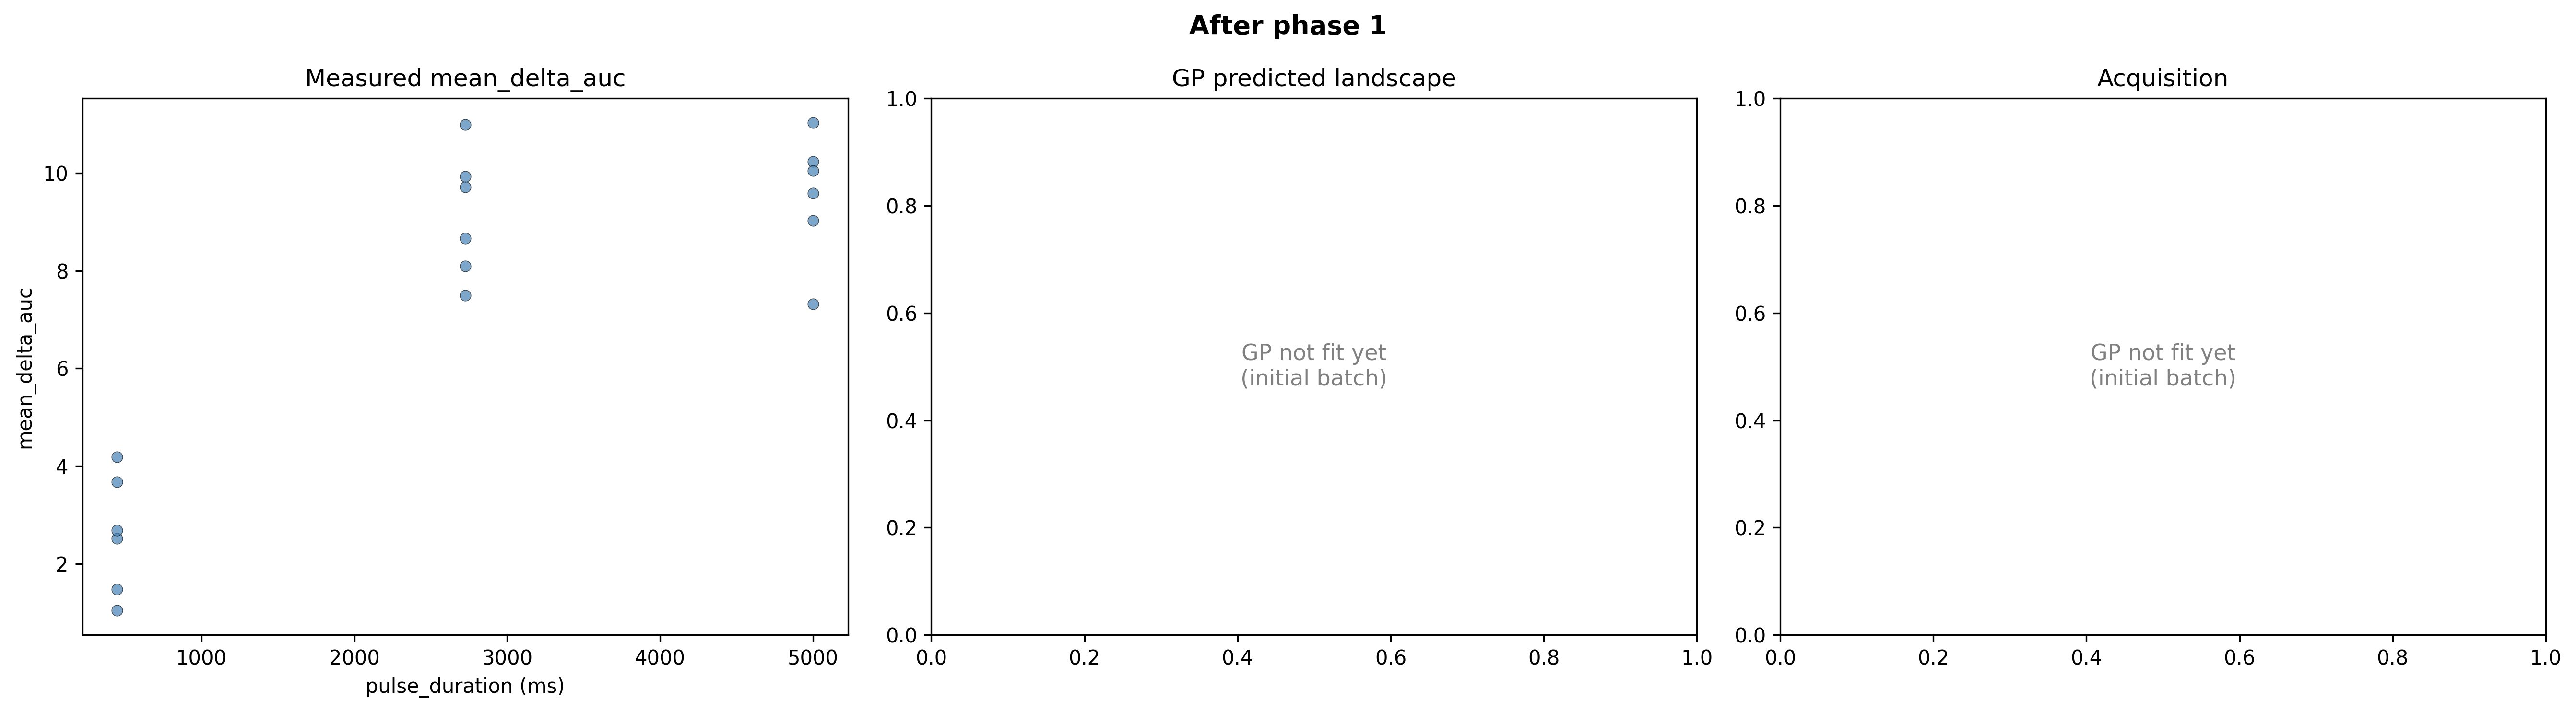


=== ComposedAgent: phase 2/8 ===
[FOVFinderAgent] Phase 1 — selected FOVs:
    B10_0000: 82 cells
    B10_0001: 132 cells
    B10_0002: 168 cells
    B9_0000: 121 cells
    B9_0001: 148 cells
    B9_0002: 178 cells
    B8_0000: 103 cells
    B8_0001: 145 cells
    B8_0002: 183 cells
    B7_0000: 135 cells
    B7_0001: 151 cells
    B7_0002: 184 cells
    B6_0000: 136 cells
    B6_0001: 157 cells
    B6_0002: 194 cells
    B5_0000: 105 cells
    B5_0001: 164 cells
    B5_0002: 193 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: warmup phase 1/2 -- fitting all 3 candidates]
      hill: obj=0.0285, log_evidence=-0.854
      exponential: obj=0.0363, log_evidence=+2.783
      power_law: obj=0.0392, log_evidence=+3.062
    [auc: warmup winner='hill', obj=0.0285]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: warmup phase 1/2 -- fitting all 3 candidates]
      hill: obj=0.0718, log_evidence=-4.856
      linear: obj=0.0865, log

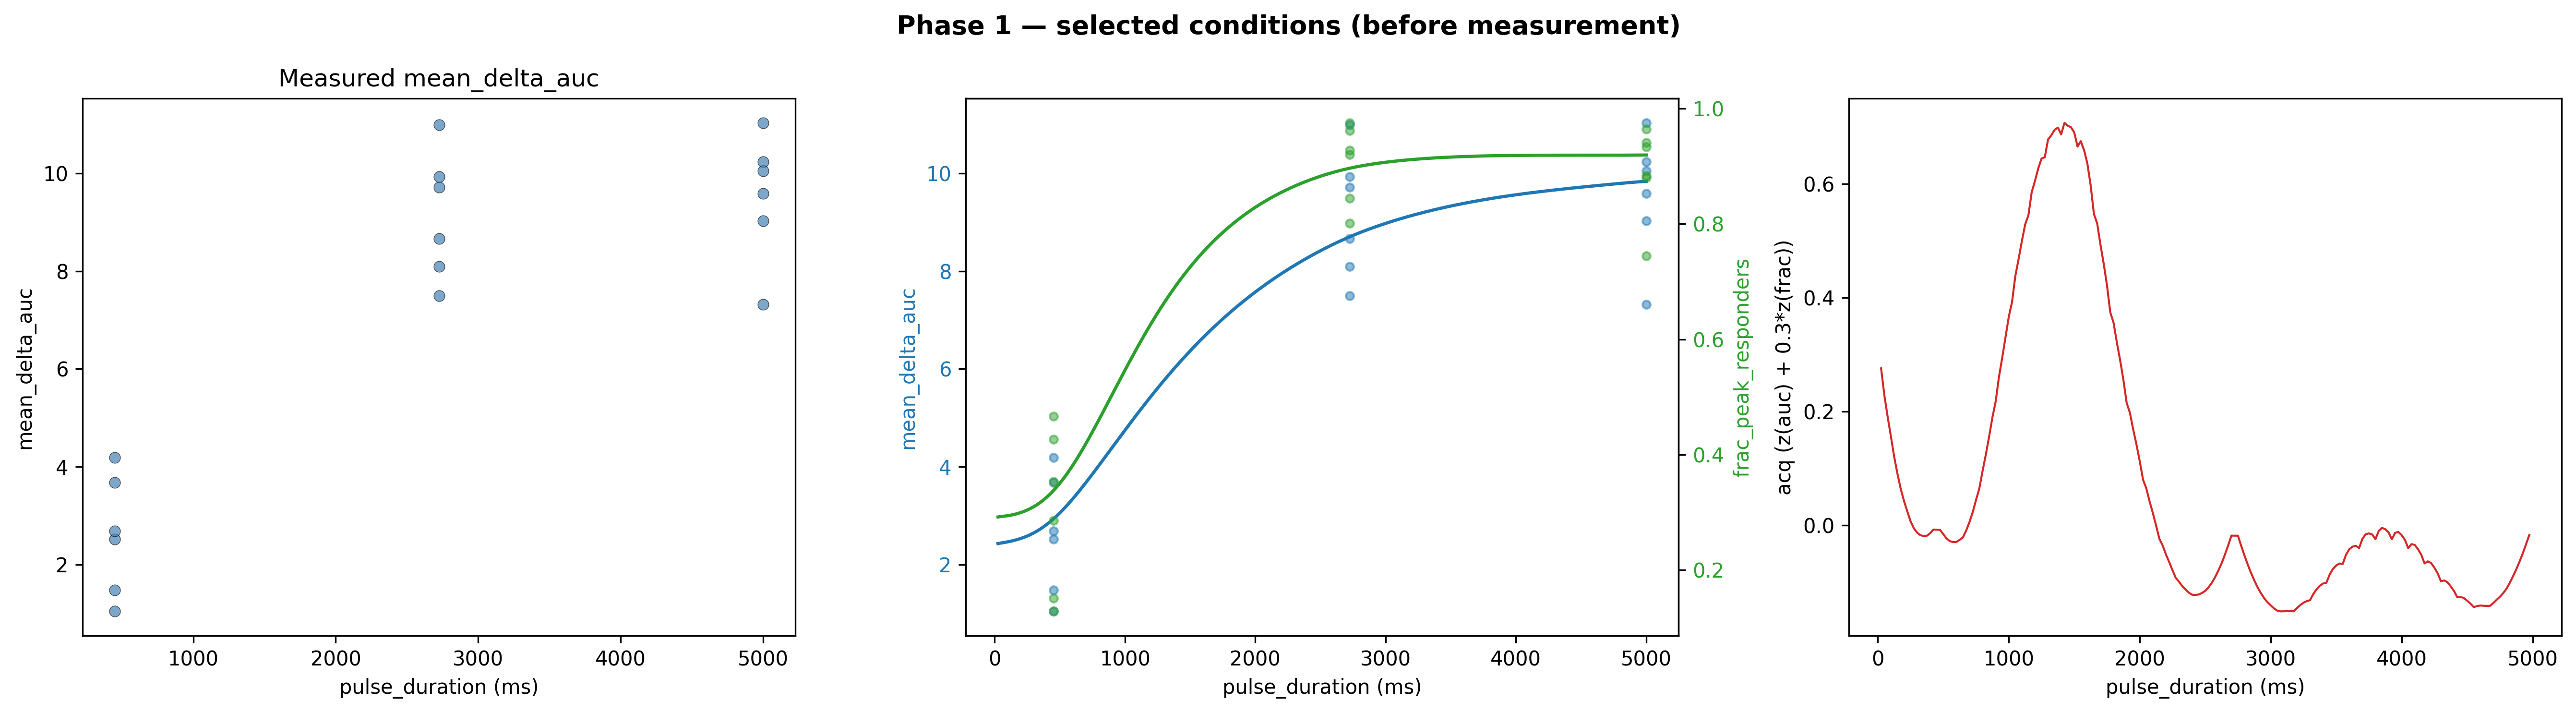

  Created 558 events for phase 1
    Cond 0 (FOVs 18-23): pulse_duration=1425ms
    Cond 1 (FOVs 24-29): pulse_duration=1000ms
    Cond 2 (FOVs 30-35): pulse_duration=25ms
  optoRTK retry summary: 1/1 recovered after re-read


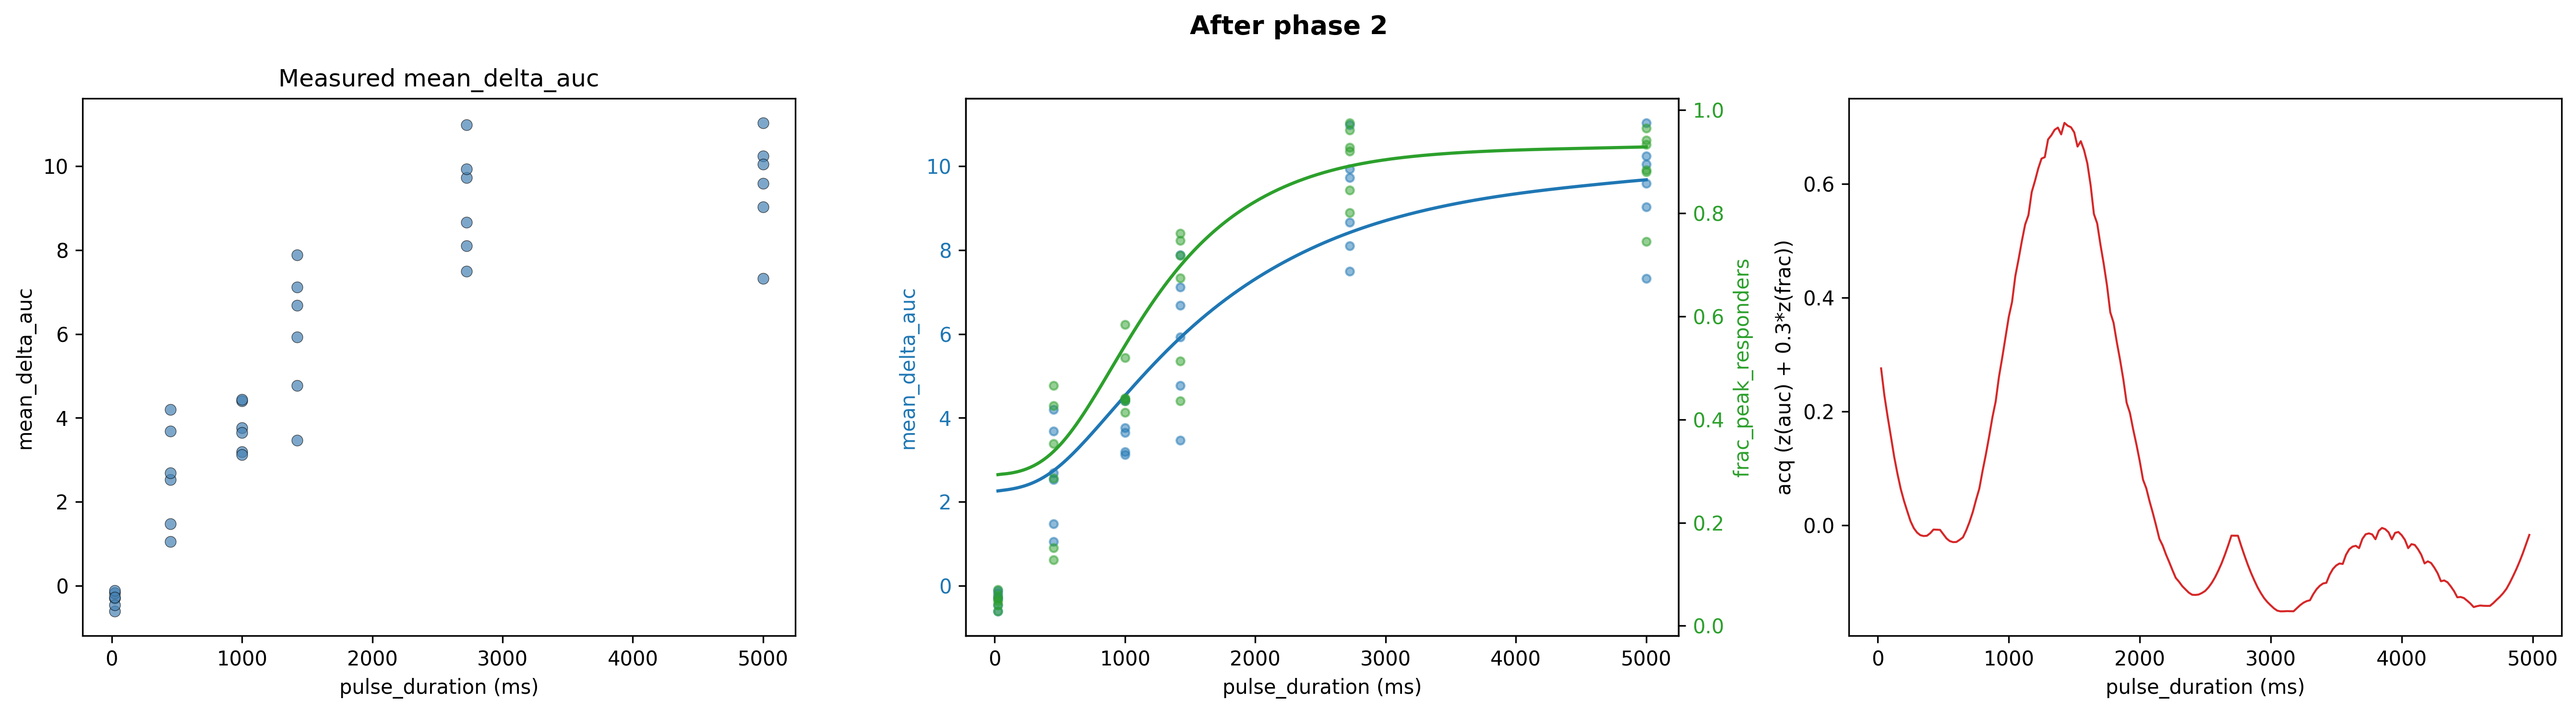


=== ComposedAgent: phase 3/8 ===
[FOVFinderAgent] Phase 2 — selected FOVs:
    C5_0000: 115 cells
    C5_0001: 147 cells
    C5_0002: 183 cells
    C6_0000: 101 cells
    C6_0001: 139 cells
    C6_0002: 164 cells
    C7_0000: 113 cells
    C7_0001: 139 cells
    C7_0002: 172 cells
    C8_0000: 96 cells
    C8_0001: 125 cells
    C8_0002: 151 cells
    C9_0000: 99 cells
    C9_0001: 133 cells
    C9_0002: 146 cells
    C10_0000: 115 cells
    C10_0001: 145 cells
    C10_0002: 157 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: warmup phase 2/2 -- fitting all 3 candidates]
      hill: obj=0.0203, log_evidence=+6.066
      exponential: obj=0.0181, log_evidence=+5.210
      power_law: obj=0.0205, log_evidence=+7.680
    [auc: warmup winner='exponential', obj=0.0181]
    [auc: WARMUP COMPLETE -- win frequencies: hill=0.50, exponential=0.50, power_law=0.00]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: warmup phase 2/2 -- fi

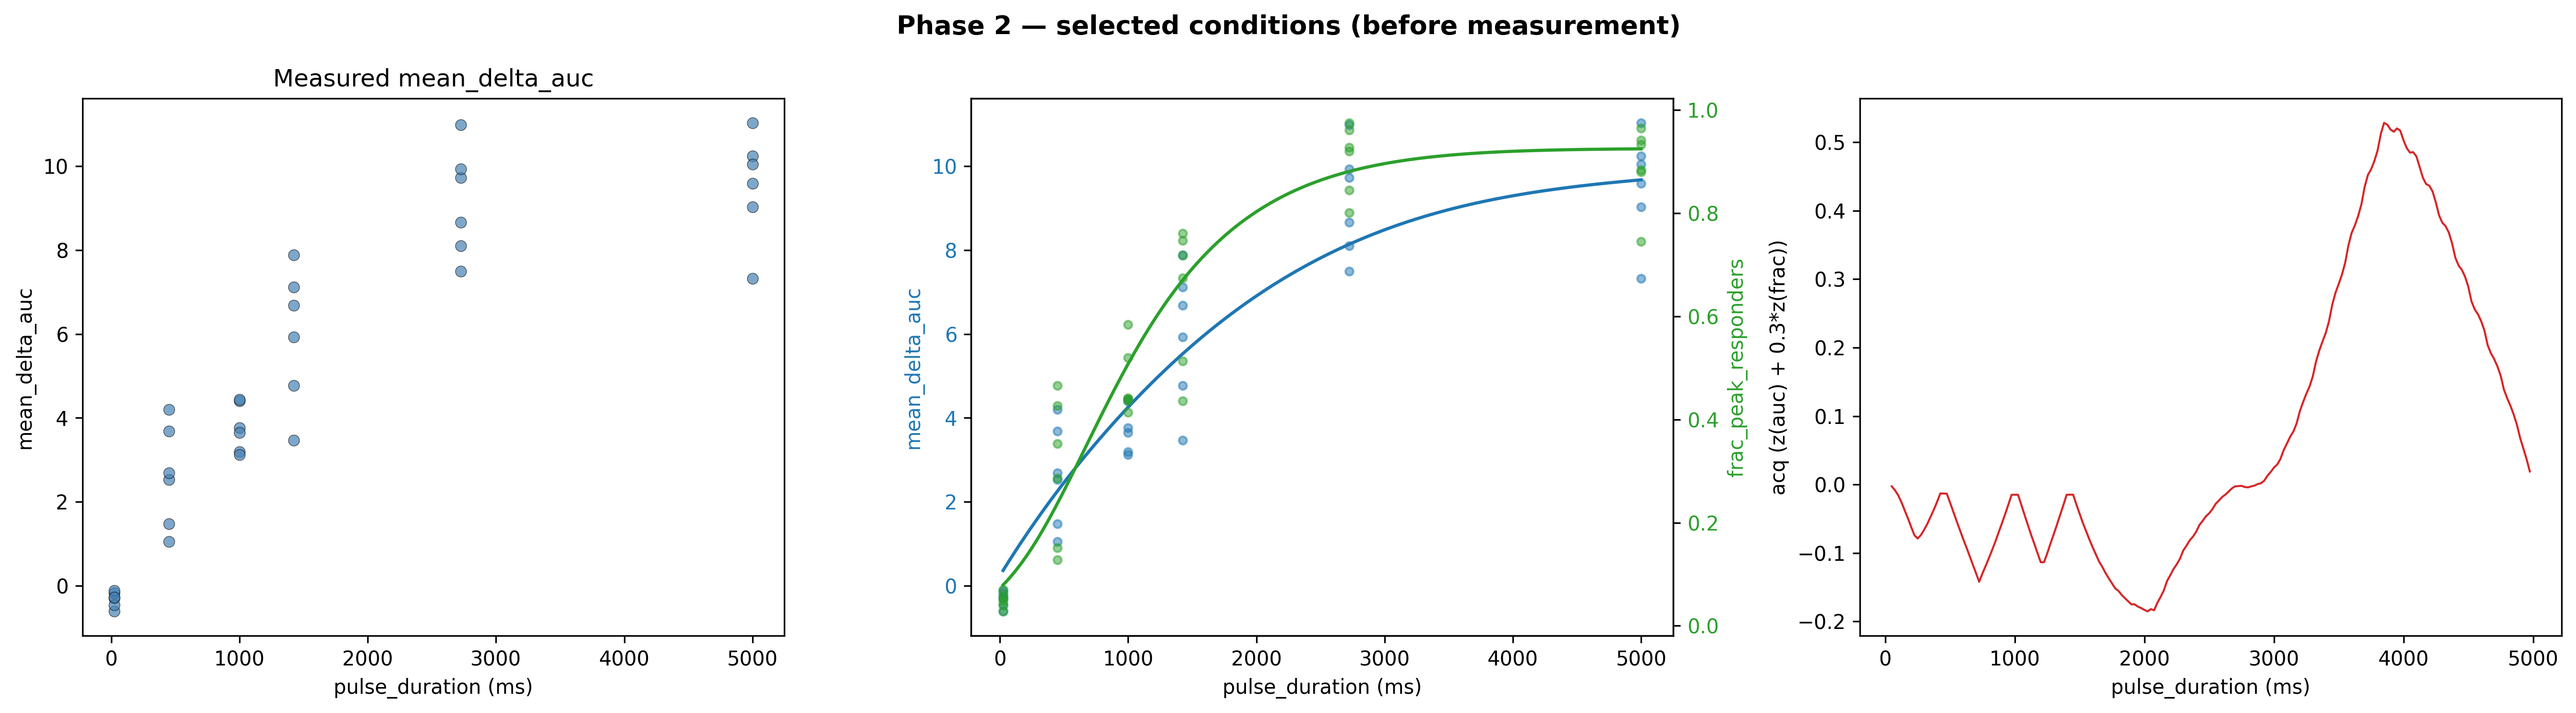

  Created 558 events for phase 2
    Cond 0 (FOVs 36-41): pulse_duration=3850ms
    Cond 1 (FOVs 42-47): pulse_duration=4425ms
    Cond 2 (FOVs 48-53): pulse_duration=3375ms
  optoRTK retry summary: 1/1 recovered after re-read


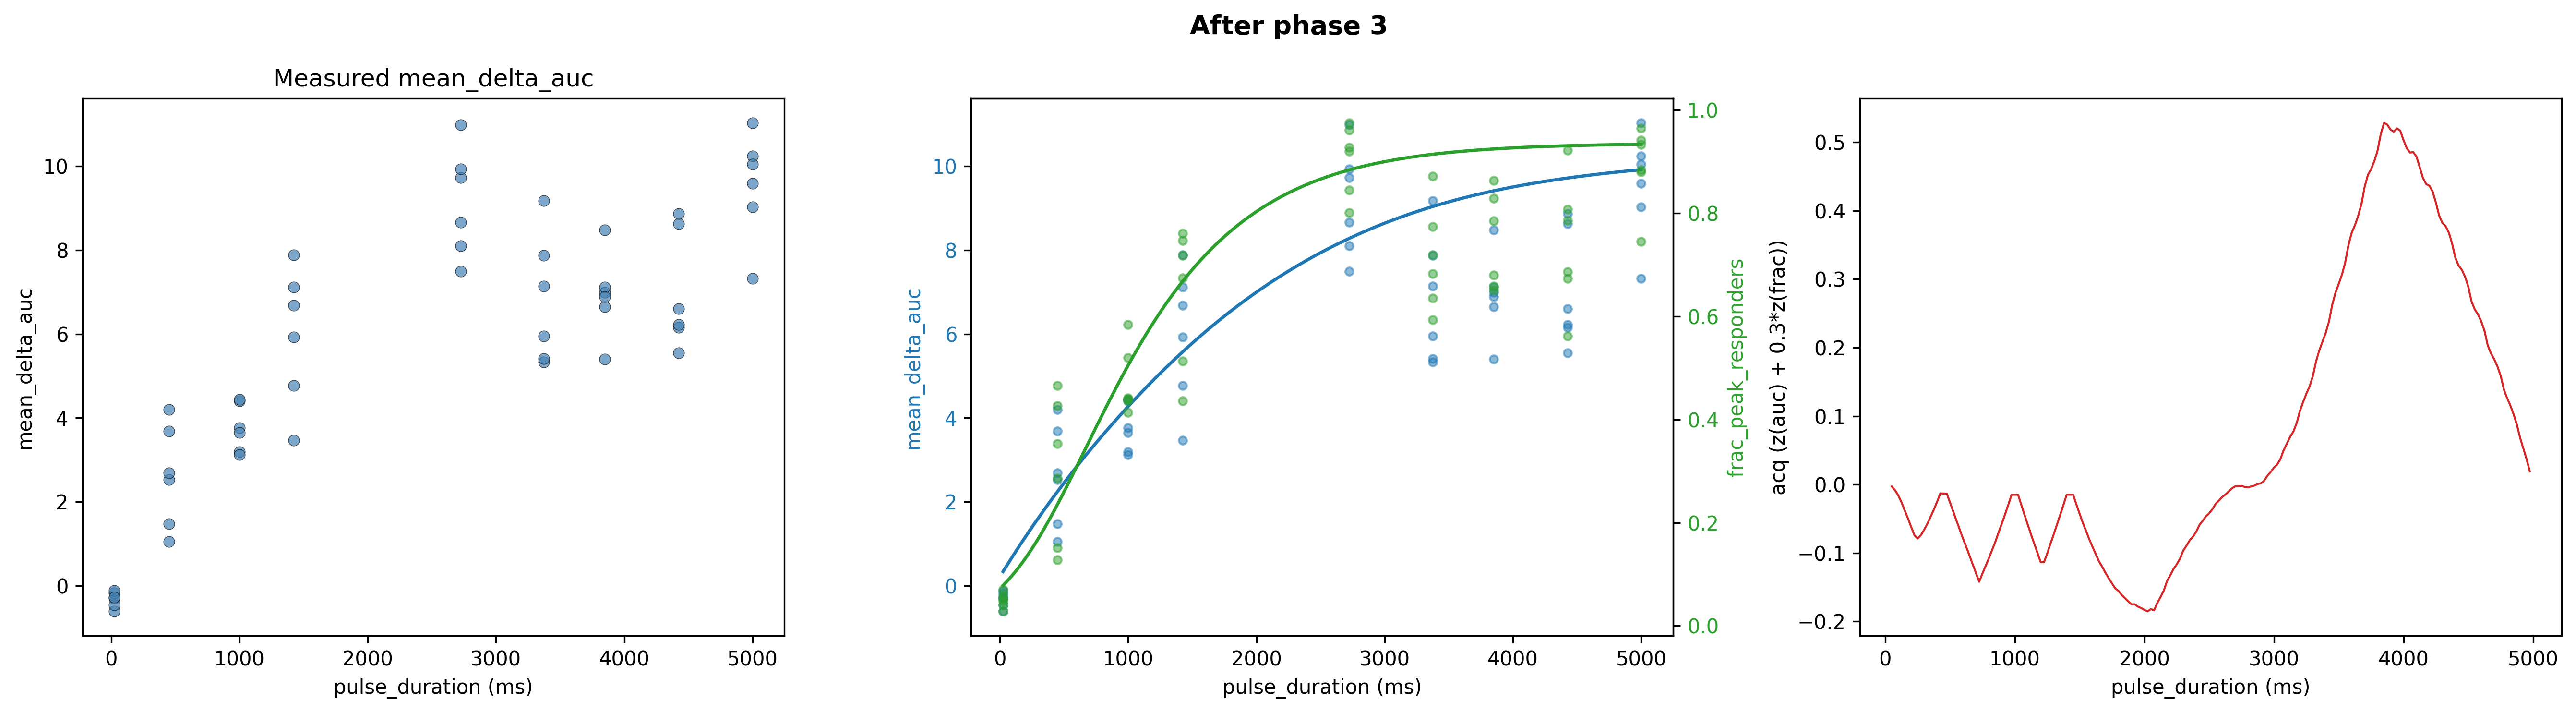


=== ComposedAgent: phase 4/8 ===
[FOVFinderAgent] Phase 3 — selected FOVs:
    D10_0000: 116 cells
    D10_0001: 132 cells
    D10_0002: 181 cells
    D9_0000: 41 cells
    D9_0001: 113 cells
    D9_0002: 171 cells
    D8_0000: 88 cells
    D8_0001: 130 cells
    D8_0002: 167 cells
    D7_0000: 73 cells
    D7_0001: 129 cells
    D7_0002: 162 cells
    D6_0000: 92 cells
    D6_0001: 138 cells
    D6_0002: 168 cells
    D5_0000: 117 cells
    D5_0001: 138 cells
    D5_0002: 168 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'power_law'  (hill=+0.50(n=2), exponential=+0.50(n=2), power_law=+0.00(n=2))]
    [auc: obj=0.0280 (prev_finite=0.0181) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.50(n=2), linear=+0.00(n=2), exponential=+0.50(n=2))]
    [frac: obj=0.0288 (prev_finite=0.0227) -> reward=-1]
  AUC-primary acq stats (frac_w=0.3): min=-0.1430, max=0.3606
  [re

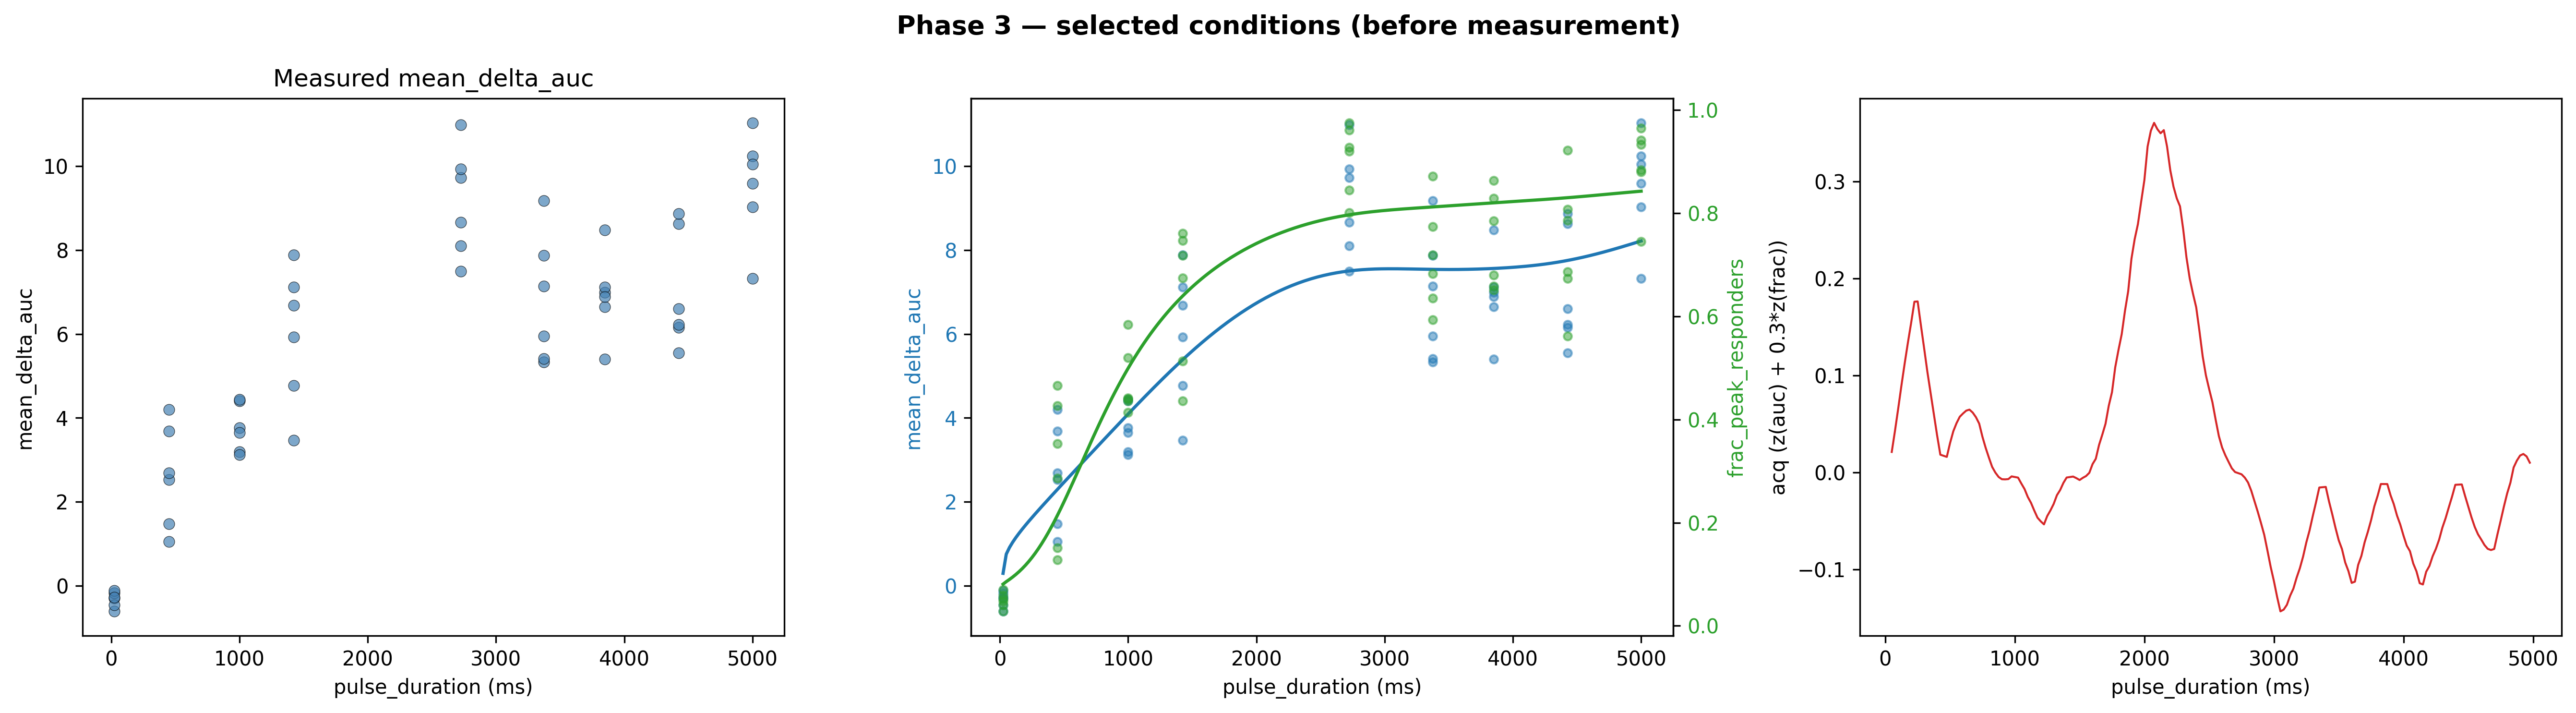

  Created 558 events for phase 3
    Cond 0 (FOVs 54-59): pulse_duration=2075ms
    Cond 1 (FOVs 60-65): pulse_duration=2400ms
    Cond 2 (FOVs 66-71): pulse_duration=225ms
  optoRTK retry summary: 1/1 recovered after re-read


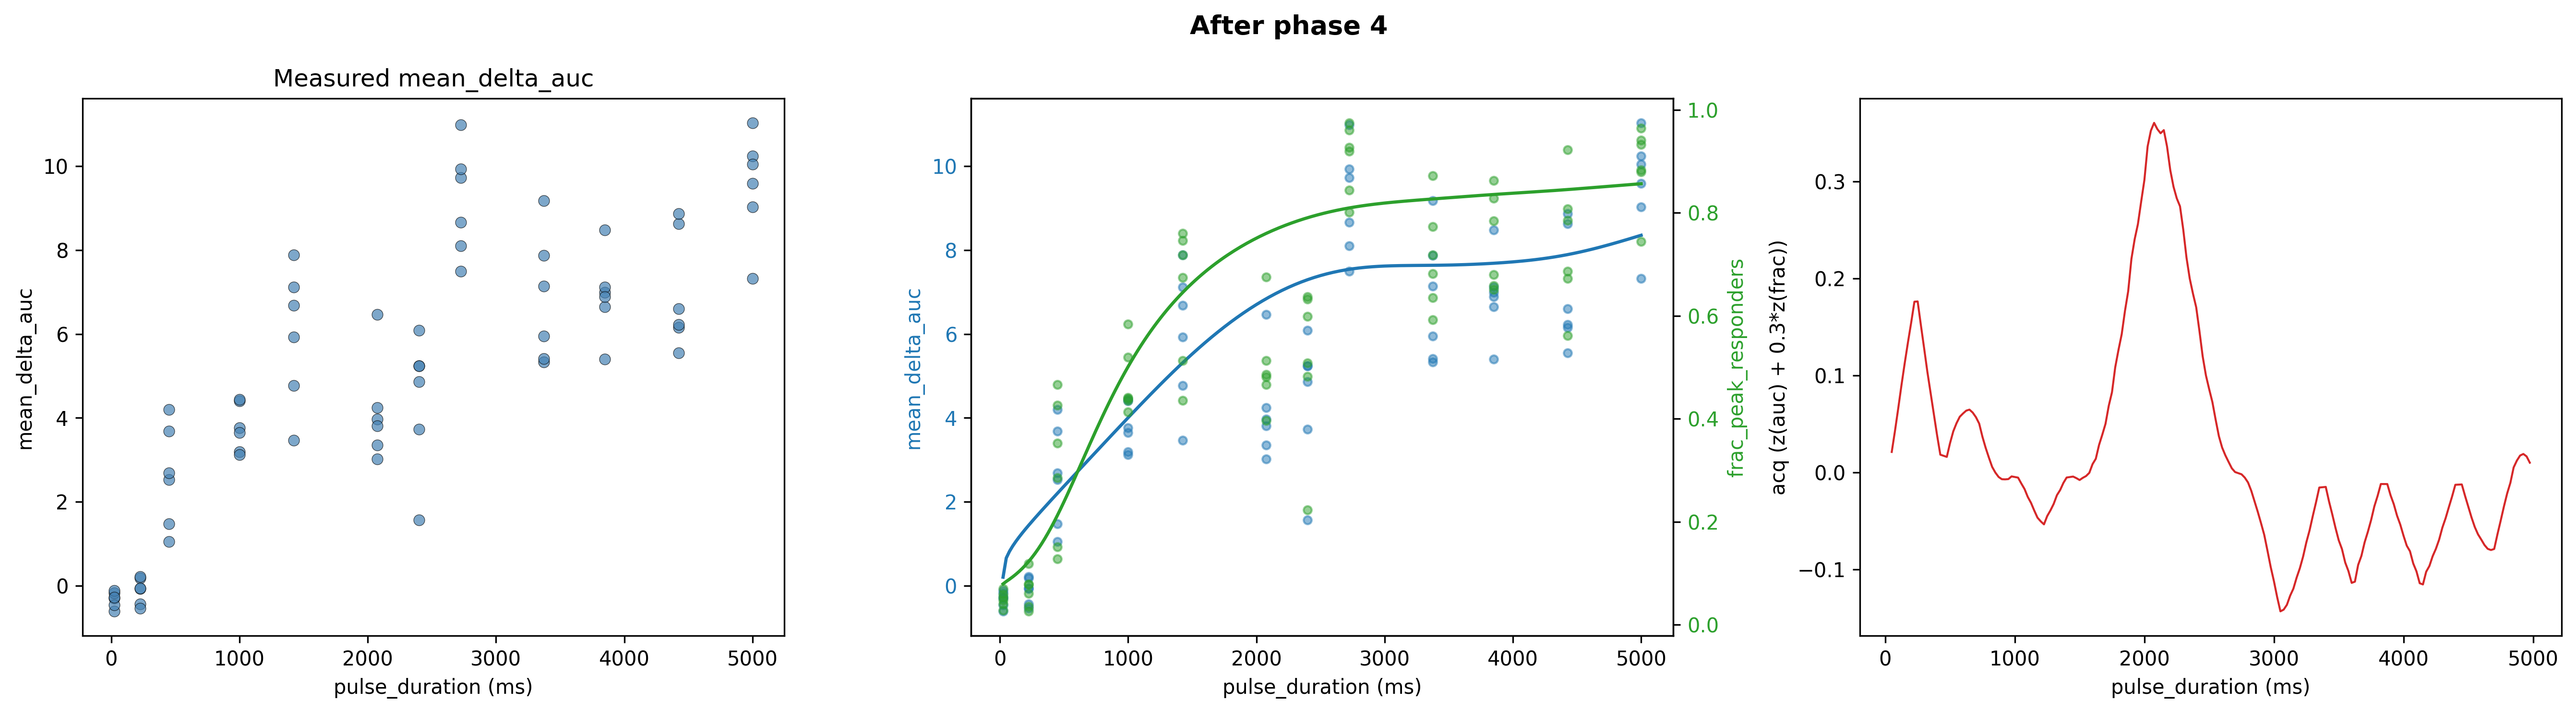


=== ComposedAgent: phase 5/8 ===
[FOVFinderAgent] Phase 4 — selected FOVs:
    E5_0000: 83 cells
    E5_0001: 146 cells
    E5_0002: 190 cells
    E6_0000: 66 cells
    E6_0001: 118 cells
    E6_0002: 155 cells
    E7_0000: 128 cells
    E7_0001: 138 cells
    E7_0002: 146 cells
    E8_0000: 62 cells
    E8_0001: 123 cells
    E8_0002: 190 cells
    E9_0000: 70 cells
    E9_0001: 119 cells
    E9_0002: 162 cells
    E10_0000: 85 cells
    E10_0001: 128 cells
    E10_0002: 145 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+0.50(n=2), exponential=+0.50(n=2), power_law=-0.33(n=3))]
    [auc: obj=0.0376 (prev_finite=0.0280) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'exponential'  (hill=+0.00(n=3), linear=+0.00(n=2), exponential=+0.50(n=2))]
    [frac: obj=0.0314 (prev_finite=0.0288) -> reward=-1]
  AUC-primary acq stats (frac_w=0.3): min=-0.1441, max=0.3084
  [r

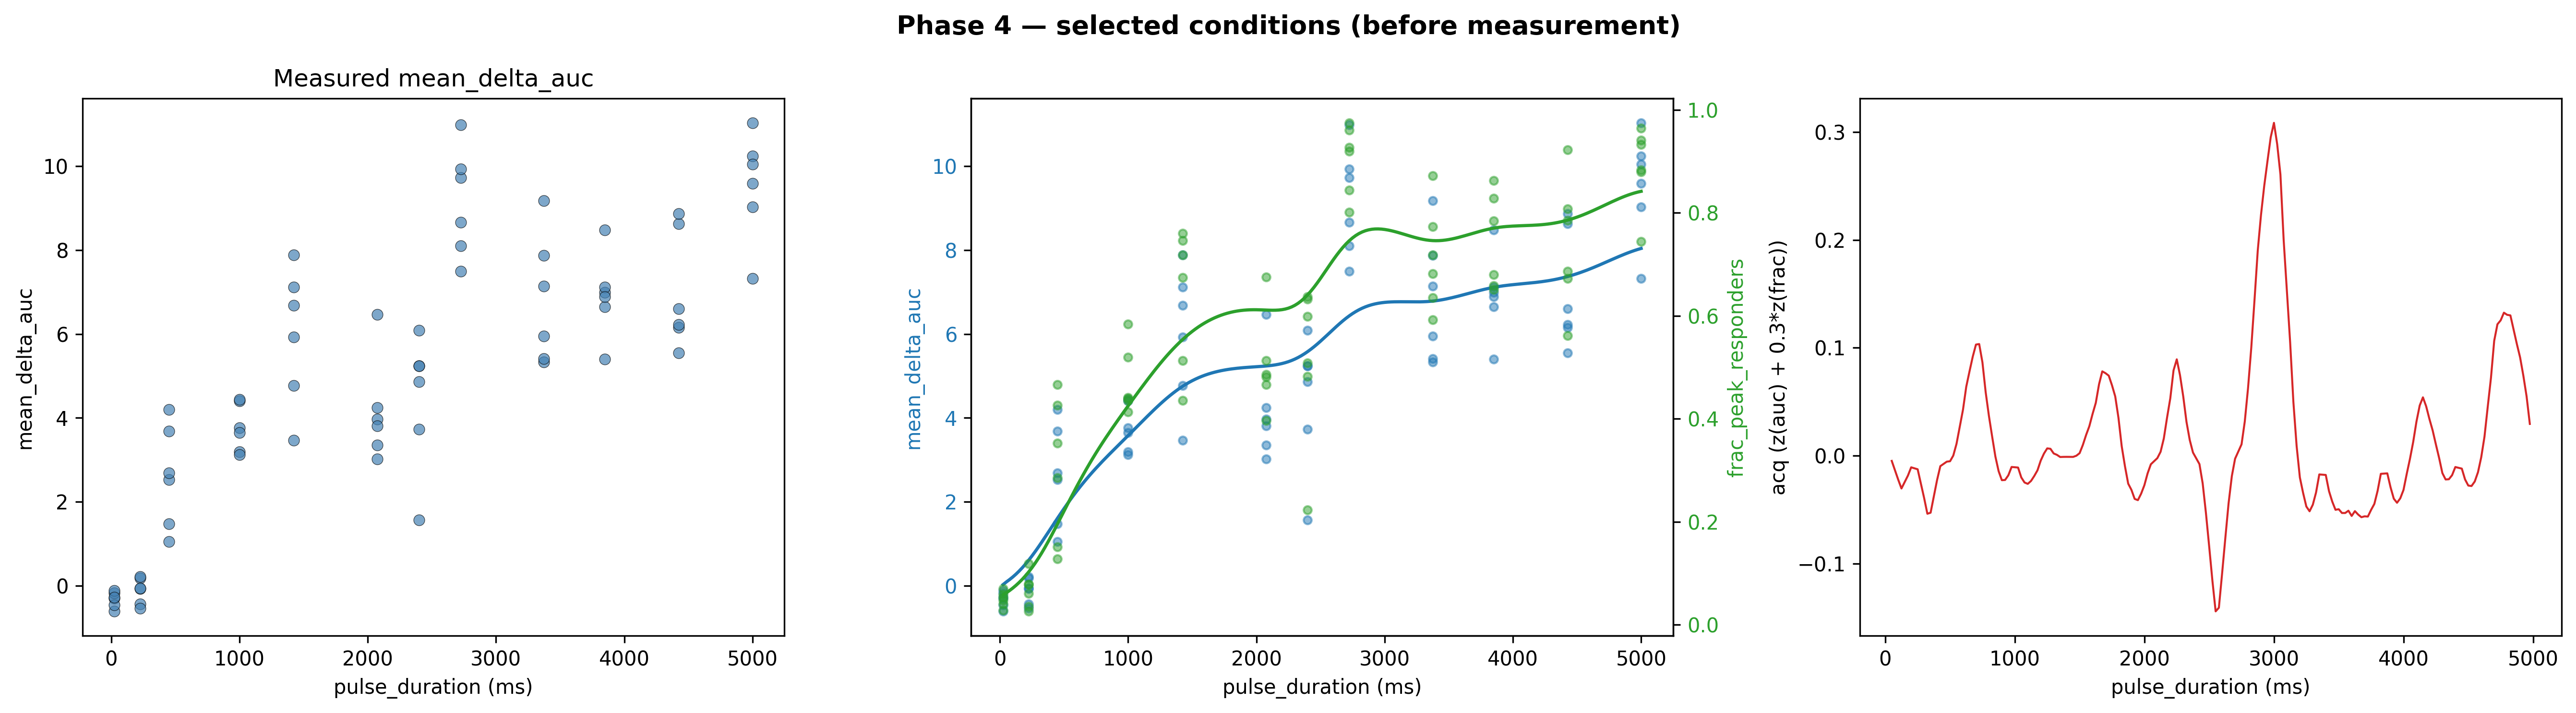

  Created 558 events for phase 4
    Cond 0 (FOVs 72-77): pulse_duration=3000ms
    Cond 1 (FOVs 78-83): pulse_duration=1725ms
    Cond 2 (FOVs 84-89): pulse_duration=725ms
  optoRTK retry summary: 1/1 recovered after re-read


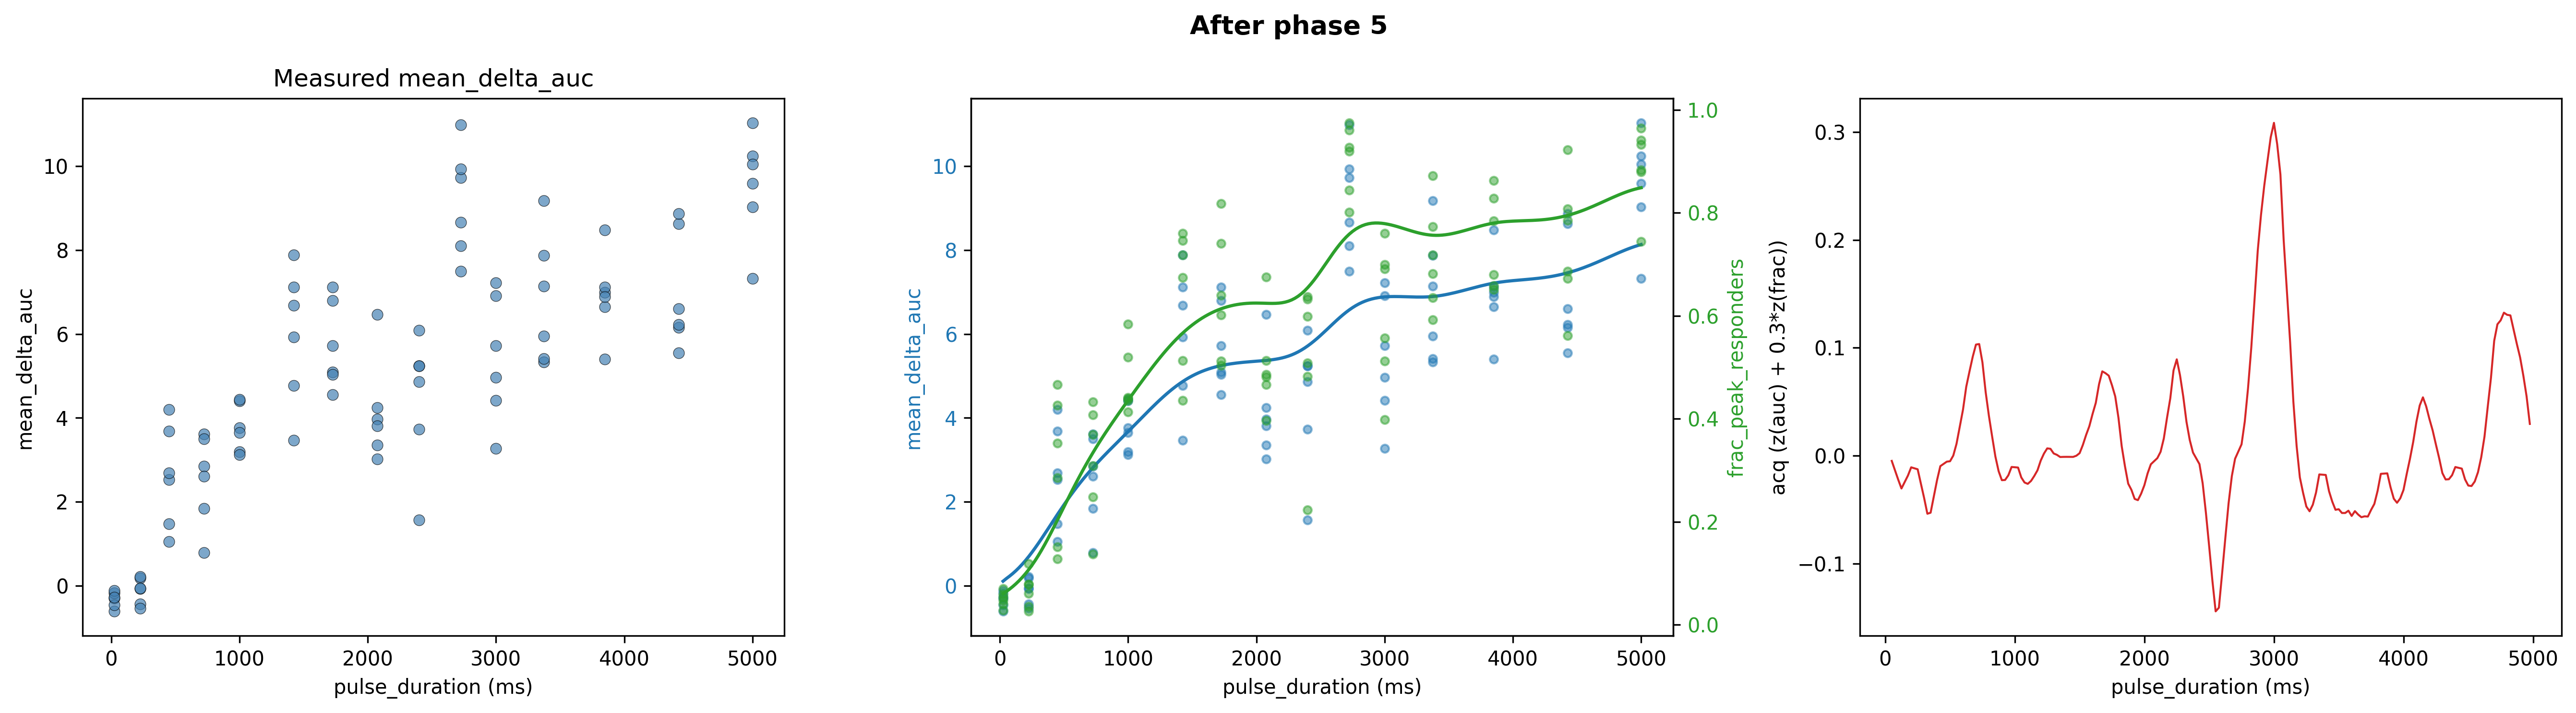


=== ComposedAgent: phase 6/8 ===
[FOVFinderAgent] Phase 5 — selected FOVs:
    F10_0000: 56 cells
    F10_0001: 131 cells
    F10_0002: 141 cells
    F9_0000: 65 cells
    F9_0001: 103 cells
    F9_0002: 188 cells
    F8_0000: 48 cells
    F8_0001: 129 cells
    F8_0002: 160 cells
    F7_0000: 90 cells
    F7_0001: 130 cells
    F7_0002: 150 cells
    F6_0000: 127 cells
    F6_0001: 141 cells
    F6_0002: 166 cells
    F5_0000: 126 cells
    F5_0001: 145 cells
    F5_0002: 165 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'exponential'  (hill=+0.00(n=3), exponential=+0.50(n=2), power_law=-0.33(n=3))]
    [auc: obj=0.0257 (prev_finite=0.0376) -> reward=+1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.00(n=3), linear=+0.00(n=2), exponential=+0.00(n=3))]
    [frac: obj=0.0226 (prev_finite=0.0314) -> reward=+1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0909, max=0.2161
  [

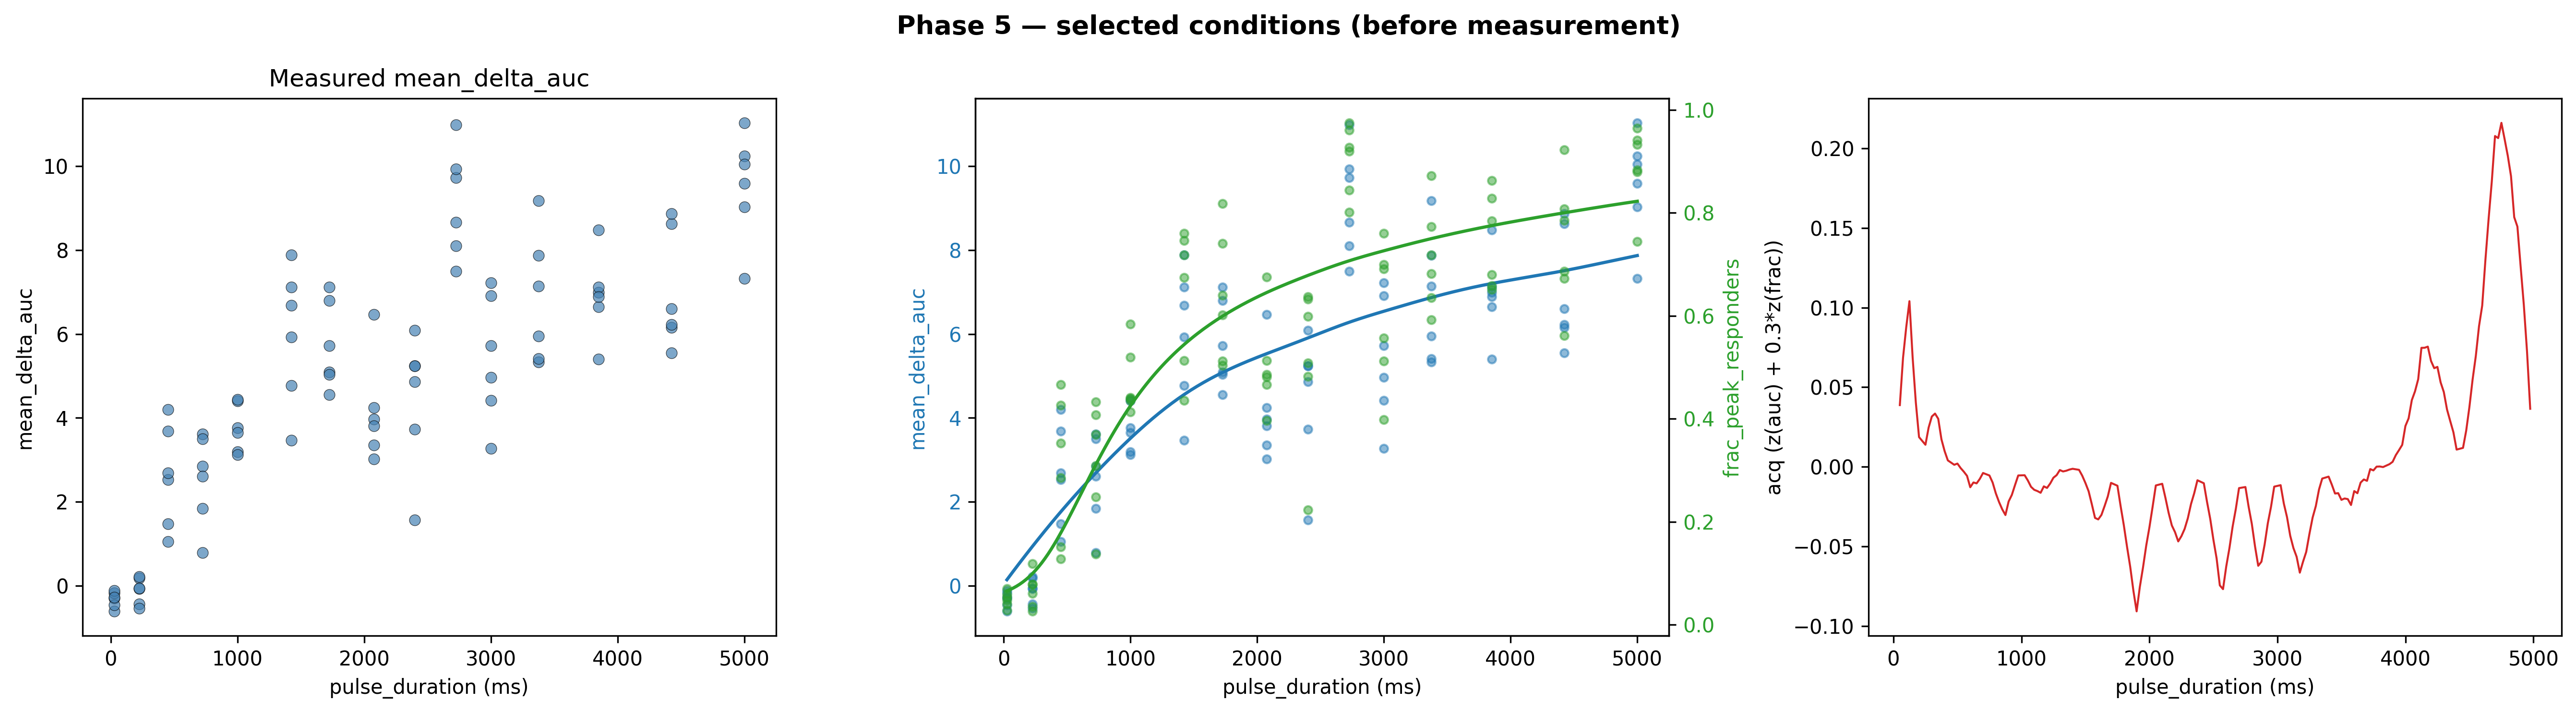

  Created 558 events for phase 5
    Cond 0 (FOVs 90-95): pulse_duration=4750ms
    Cond 1 (FOVs 96-101): pulse_duration=4875ms
    Cond 2 (FOVs 102-107): pulse_duration=4600ms
  optoRTK retry summary: 1/1 recovered after re-read


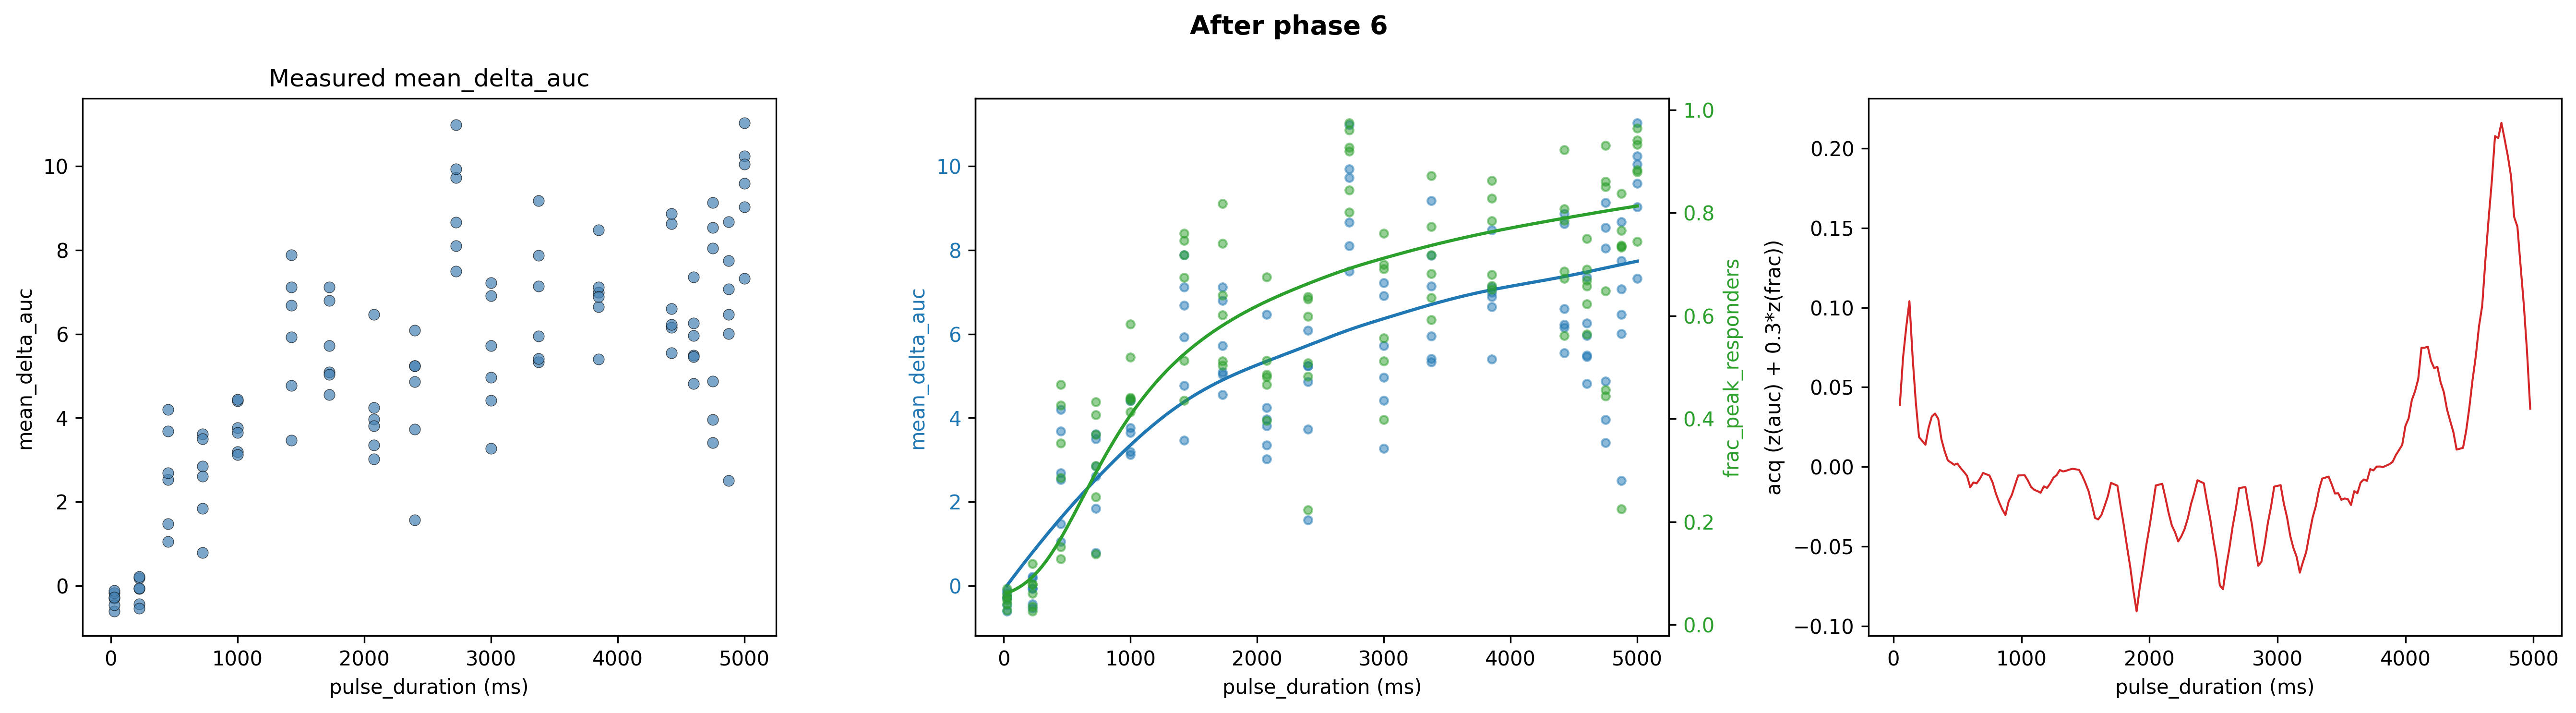


=== ComposedAgent: phase 7/8 ===
[FOVFinderAgent] Phase 6 — selected FOVs:
    G5_0000: 96 cells
    G5_0001: 133 cells
    G5_0002: 192 cells
    G6_0000: 101 cells
    G6_0001: 142 cells
    G6_0002: 169 cells
    G7_0000: 81 cells
    G7_0001: 121 cells
    G7_0002: 194 cells
    G8_0000: 78 cells
    G8_0001: 140 cells
    G8_0002: 155 cells
    G9_0000: 87 cells
    G9_0001: 109 cells
    G9_0002: 155 cells
    G10_0000: 84 cells
    G10_0001: 112 cells
    G10_0002: 177 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'exponential'  (hill=+0.00(n=3), exponential=+0.67(n=3), power_law=-0.33(n=3))]
    [auc: obj=0.0419 (prev_finite=0.0257) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.25(n=4), linear=+0.00(n=2), exponential=+0.00(n=3))]
    [frac: obj=0.0244 (prev_finite=0.0226) -> reward=-1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0805, max=0.1556
  [r

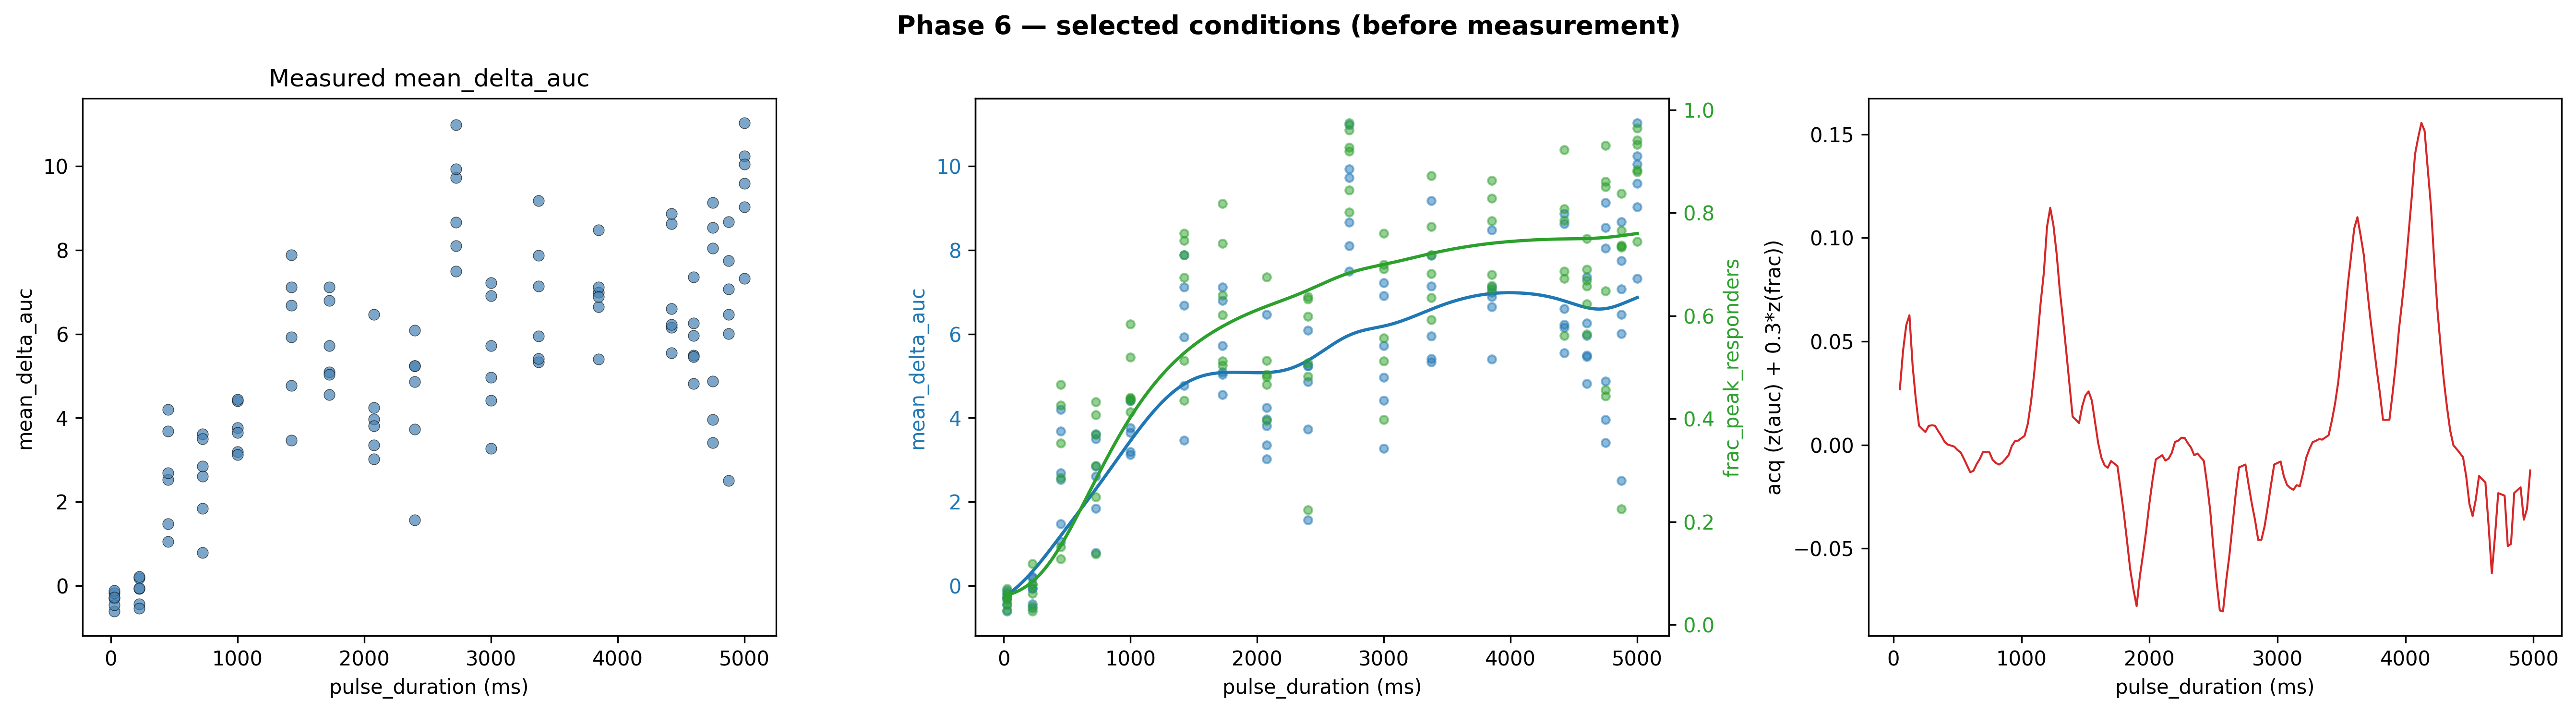

  Created 558 events for phase 6
    Cond 0 (FOVs 108-113): pulse_duration=4125ms
    Cond 1 (FOVs 114-119): pulse_duration=3625ms
    Cond 2 (FOVs 120-125): pulse_duration=1225ms
  optoRTK retry summary: 1/1 recovered after re-read


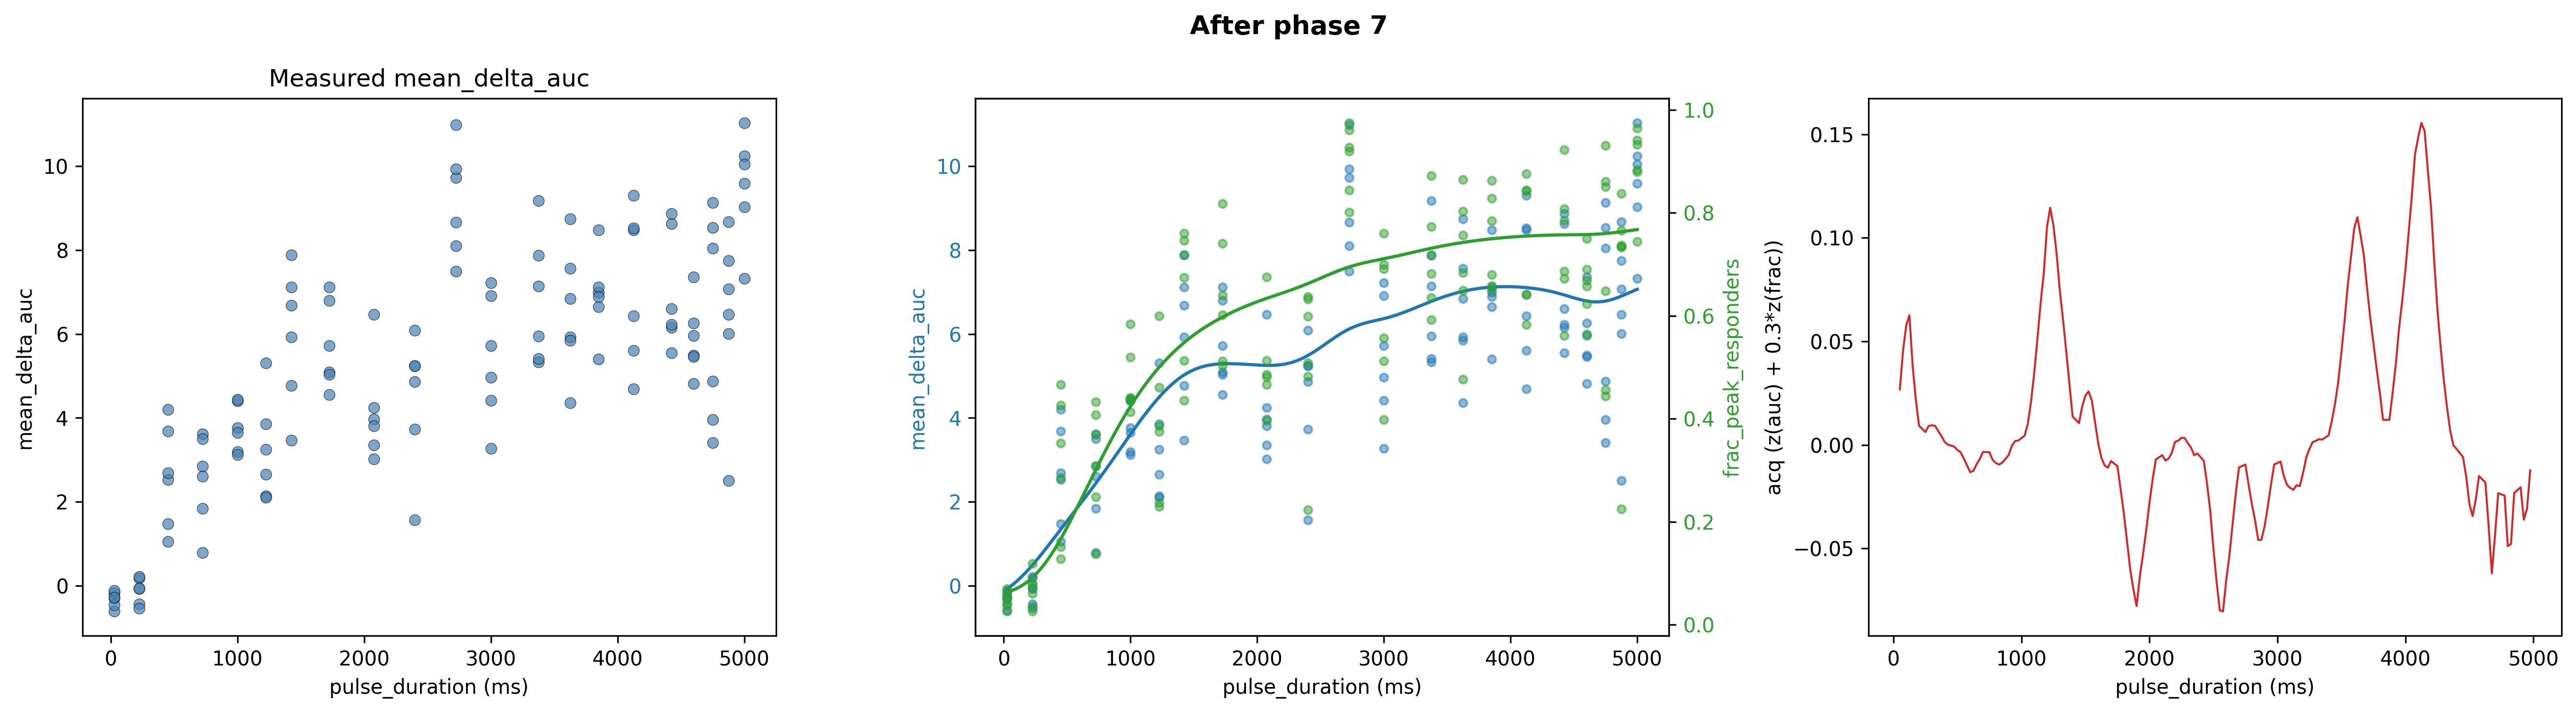


=== ComposedAgent: phase 8/8 ===
[FOVFinderAgent] Phase 7 — selected FOVs:
    H10_0000: 41 cells
    H10_0001: 154 cells
    H10_0002: 27 cells (below min_cells)
    H9_0000: 38 cells
    H9_0001: 77 cells
    H9_0002: 116 cells
    H8_0000: 59 cells
    H8_0001: 130 cells
    H8_0002: 147 cells
    H7_0000: 48 cells
    H7_0001: 91 cells
    H7_0002: 101 cells
    H6_0000: 36 cells
    H6_0001: 111 cells
    H6_0002: 128 cells
    H5_0000: 58 cells
    H5_0001: 98 cells
    H5_0002: 118 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'exponential'  (hill=+0.00(n=3), exponential=+0.25(n=4), power_law=-0.33(n=3))]
    [auc: obj=0.0350 (prev_finite=0.0419) -> reward=+1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.00(n=5), linear=+0.00(n=2), exponential=+0.00(n=3))]
    [frac: obj=0.0284 (prev_finite=0.0244) -> reward=-1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0915, ma

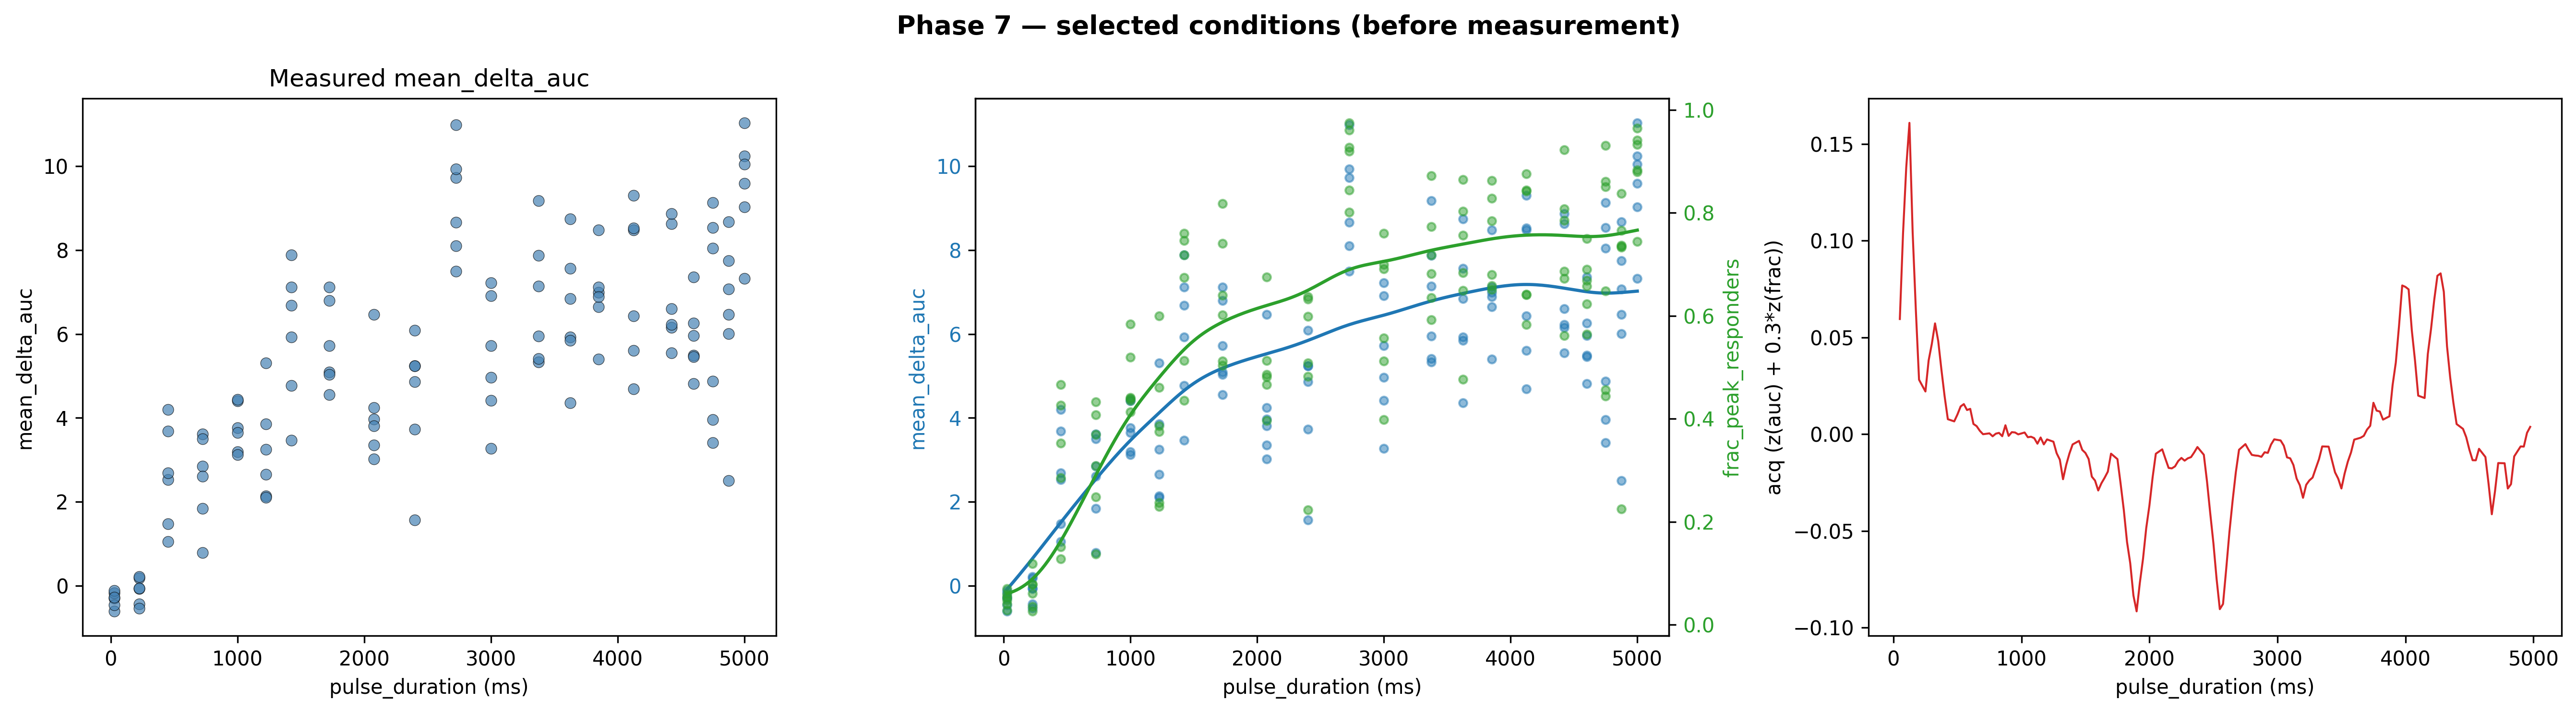

  Created 558 events for phase 7
    Cond 0 (FOVs 126-131): pulse_duration=125ms
    Cond 1 (FOVs 132-137): pulse_duration=75ms
    Cond 2 (FOVs 138-143): pulse_duration=4275ms
  optoRTK retry summary: 1/1 recovered after re-read


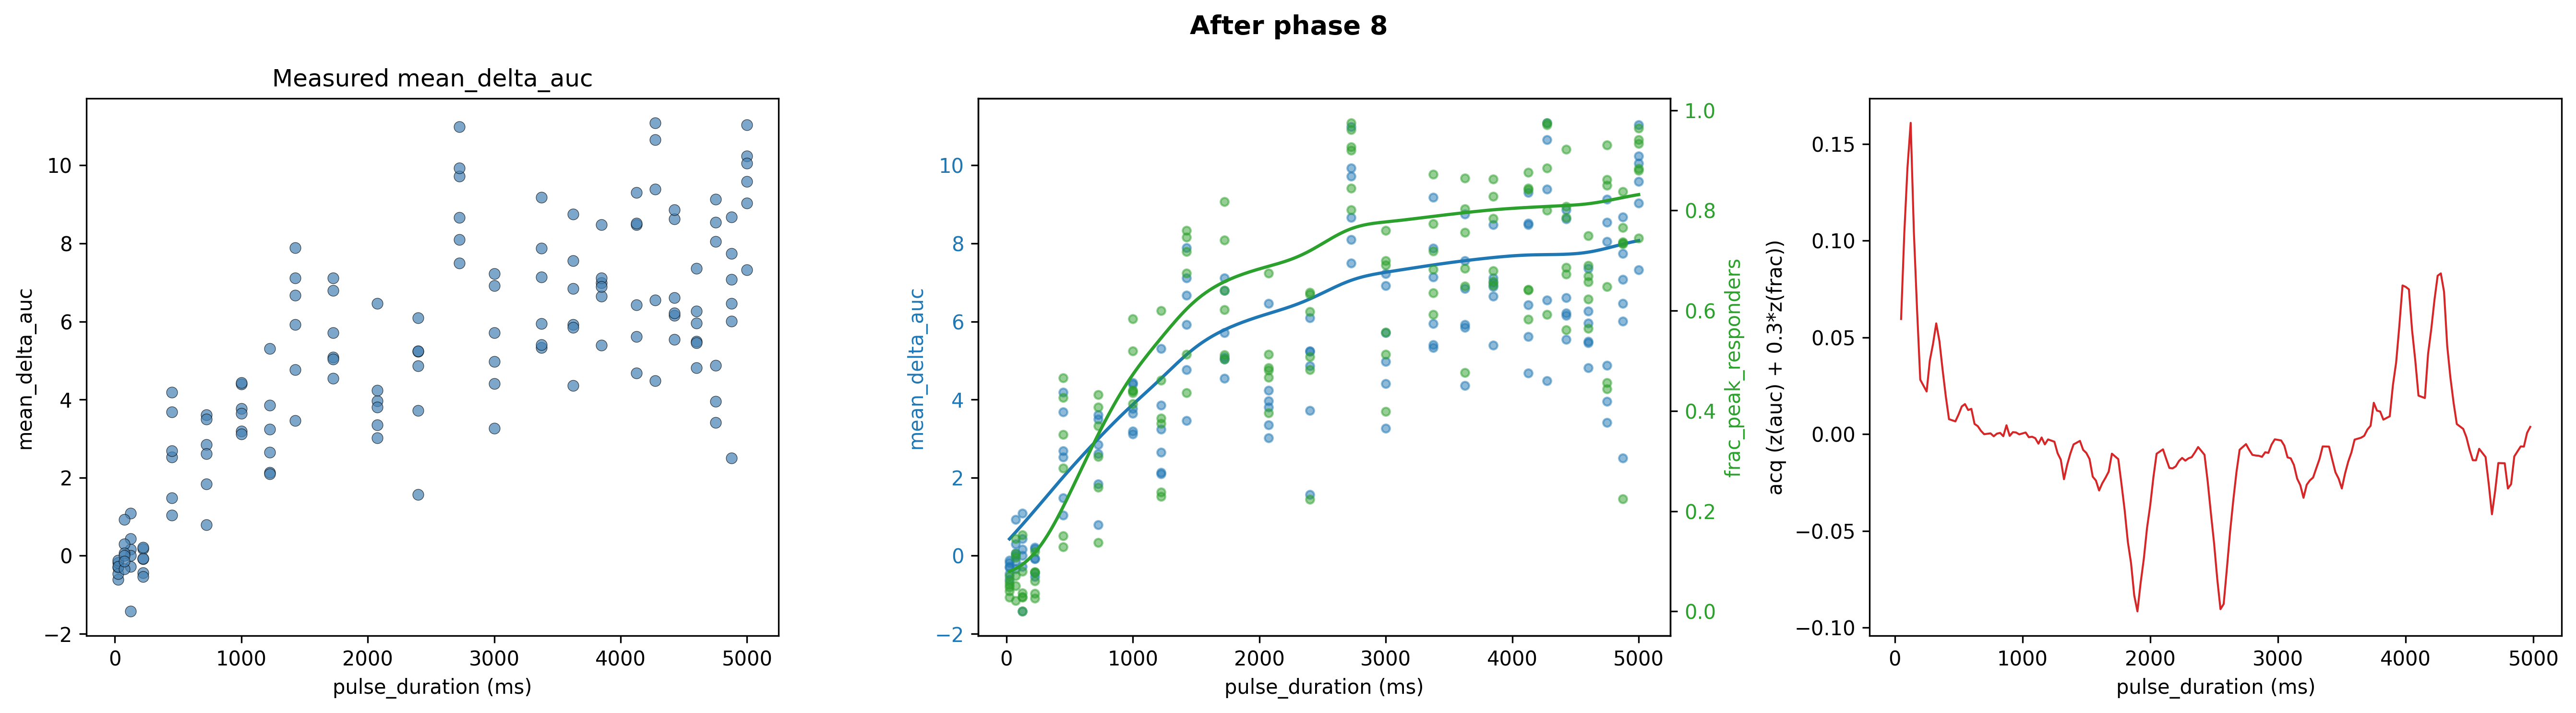

In [17]:
# Disconnect napari live view so it does not interfere with the acquisition engine.
try:
    mm_wdg._core_link.cleanup()
except Exception:
    pass

composed_agent.run()

In [18]:
# Post-processing: merge per-FOV tracks into a single dataframe.
utils.generate_exp_data_from_tracks(path)

## Visualise dose-response and hypothesis evidence

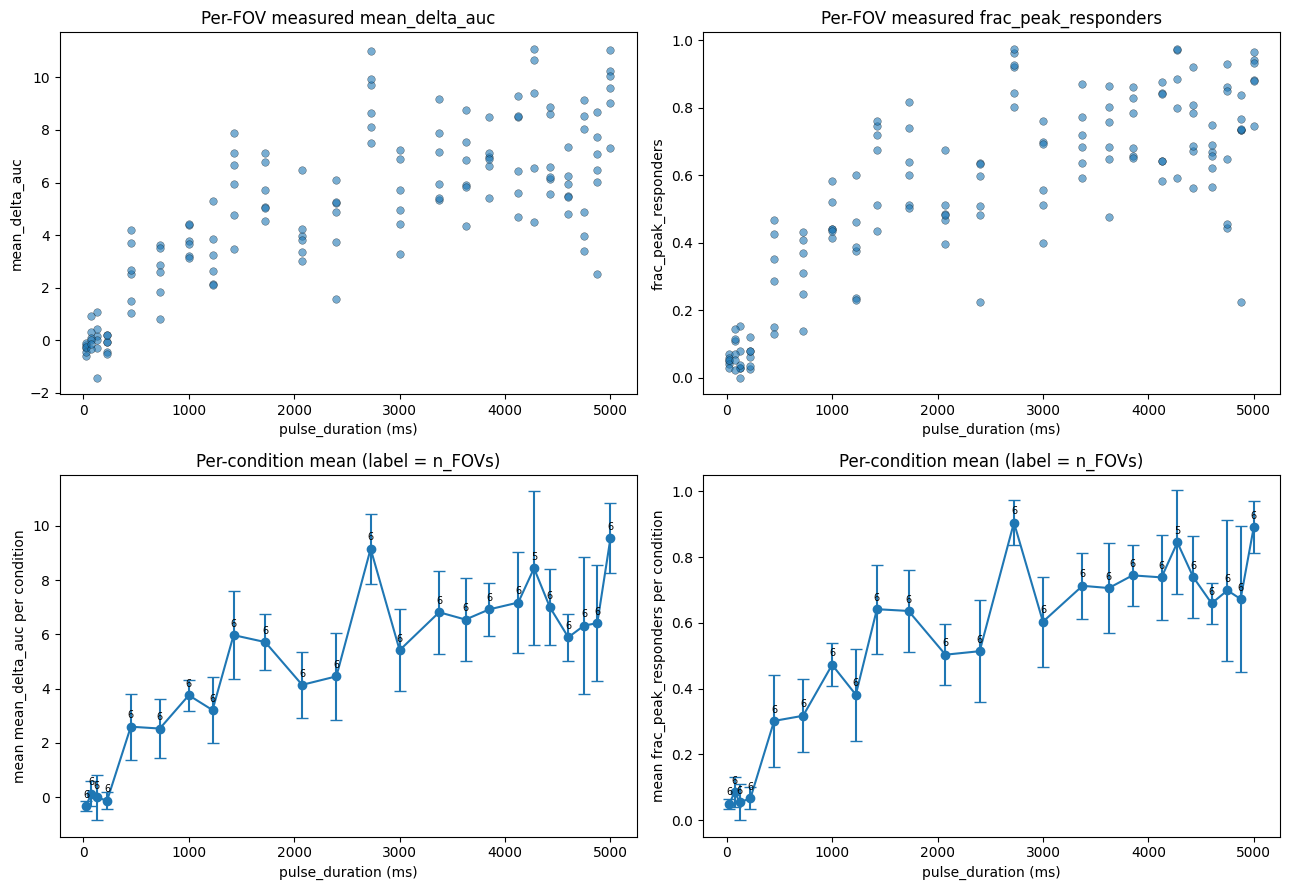

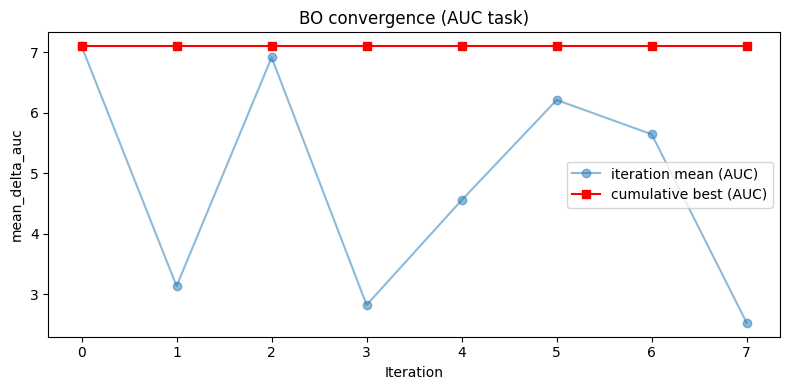

In [19]:
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for col, task_col, ylabel in [
        (0, "mean_delta_auc", "mean_delta_auc"),
        (1, "frac_peak_responders", "frac_peak_responders"),
    ]:
        # Top row: per-FOV scatter
        axes[0, col].scatter(
            df["pulse_duration"],
            df[task_col],
            alpha=0.6,
            s=30,
            edgecolors="k",
            linewidths=0.3,
        )
        axes[0, col].set_xlabel("pulse_duration (ms)")
        axes[0, col].set_ylabel(ylabel)
        axes[0, col].set_title(f"Per-FOV measured {ylabel}")

        # Bottom row: per-condition mean +/- std
        cond_agg = (
            df.groupby("pulse_duration")
            .agg(
                mean_y=(task_col, "mean"),
                std_y=(task_col, "std"),
                n_fovs=(task_col, "count"),
            )
            .reset_index()
        )
        axes[1, col].errorbar(
            cond_agg["pulse_duration"],
            cond_agg["mean_y"],
            yerr=cond_agg["std_y"].fillna(0.0),
            fmt="o-",
            capsize=4,
        )
        axes[1, col].set_xlabel("pulse_duration (ms)")
        axes[1, col].set_ylabel(f"mean {ylabel} per condition")
        axes[1, col].set_title("Per-condition mean (label = n_FOVs)")
        for _, r in cond_agg.iterrows():
            axes[1, col].annotate(
                int(r["n_fovs"]),
                (r["pulse_duration"], r["mean_y"]),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=7,
            )
    axes[1, 1].set_ylim(-0.05, 1.05)  # frac_peak_responders is bounded
    plt.tight_layout()
    plt.show()

    if agent._iteration_means:
        fig, ax = plt.subplots(figsize=(8, 4))
        means = np.array(agent._iteration_means)
        ax.plot(means, "o-", alpha=0.5, label="iteration mean (AUC)")
        ax.plot(
            np.maximum.accumulate(means),
            "s-",
            color="red",
            label="cumulative best (AUC)",
        )
        ax.set_xlabel("Iteration")
        ax.set_ylabel("mean_delta_auc")
        ax.set_title("BO convergence (AUC task)")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No data collected yet.")

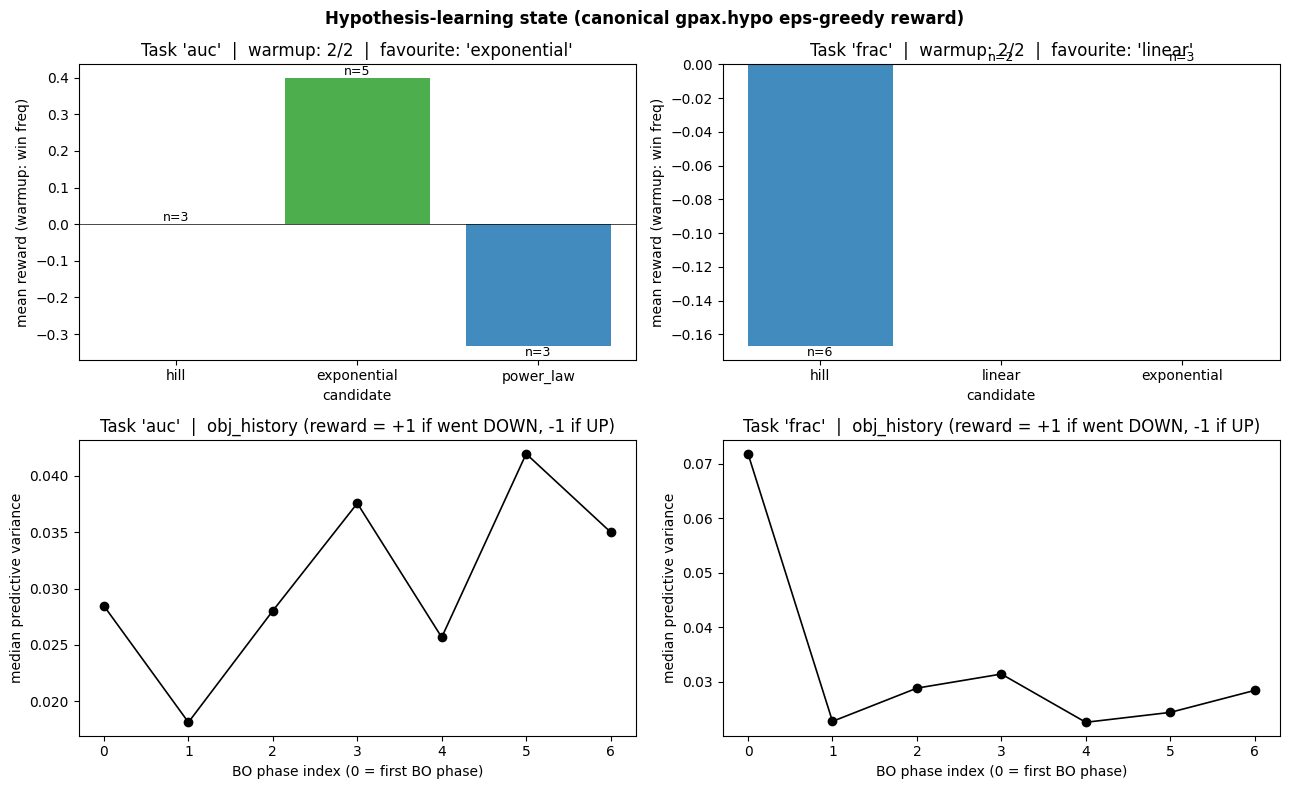

In [20]:
# Per-task hypothesis-learning diagnostics:
#   left:  mean reward per candidate (current eps-greedy favourite highlighted)
#   right: median predictive variance trajectory (the obj_history that drives reward)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col_i, task in enumerate(agent.TASKS):
    state = agent._task_state[task]
    candidates = list(agent.candidate_hypotheses_by_task[task])
    record = state["record"]
    obj_history = state["obj_history"]
    log = state["hypothesis_log"]
    favourite = state["selected_hypothesis"]
    n_warmup_done = state.get("n_warmup_phases_done", 0)

    # --- top: mean reward per candidate ---
    ax = axes[0, col_i]
    if not log:
        ax.text(
            0.5,
            0.5,
            "No hypothesis updates yet\n(run hasn't reached BO phase)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        colors = ["C2" if name == favourite else "C0" for name in candidates]
        bars = ax.bar(candidates, record[:, 1], color=colors, alpha=0.85)
        for bar, n in zip(bars, record[:, 0]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"n={int(n)}",
                ha="center",
                va="bottom" if bar.get_height() >= 0 else "top",
                fontsize=9,
            )
        ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("mean reward (warmup: win freq)")
    ax.set_xlabel("candidate")
    ax.set_title(
        f"Task {task!r}  |  warmup: {n_warmup_done}/{agent.n_warmup_phases}  "
        f"|  favourite: {favourite!r}"
    )

    # --- bottom: obj_history (median predictive variance per phase) ---
    ax = axes[1, col_i]
    if len(obj_history) < 2:
        ax.text(
            0.5,
            0.5,
            "Need >=2 phases for obj_history",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        # During warmup, hypothesis_log has multiple entries per phase (one per
        # candidate). Use obj_history's index as the phase index for plotting.
        phase_axis = list(range(len(obj_history)))
        ax.plot(phase_axis, obj_history, "o-", color="k", lw=1.2)
        ax.set_xlabel("BO phase index (0 = first BO phase)")
        ax.set_ylabel("median predictive variance")
        ax.set_title(
            f"Task {task!r}  |  obj_history " f"(reward = +1 if went DOWN, -1 if UP)"
        )

fig.suptitle(
    "Hypothesis-learning state (canonical gpax.hypo eps-greedy reward)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

=== v2 EARLY-STOPPING REPORT (task = 'auc') ===
Candidates: ['hill', 'exponential', 'power_law']
Final favourite: 'exponential'

End-of-run record:
          hill: n= 3  reward=+0.000
   exponential: n= 5  reward=+0.400  <-- selected
     power_law: n= 3  reward=-0.333

Top-1 - top-2 reward gap: 0.400  (NOISE-LEVEL (<0.6))

Eps-greedy phases: 5
Eps-greedy picks (phase -> candidate):
  phase  3: power_law
  phase  4: hill
  phase  5: exponential  (final favourite)
  phase  6: exponential  (final favourite)
  phase  7: exponential  (final favourite)

Last 2 eps-greedy picks: ['exponential', 'exponential']  -> stable on 'exponential'? True
Coverage: candidates picked = ['exponential', 'hill', 'power_law']  (ALL PICKED)

VERDICT: NOT fully converged. Failed: reward gap 0.40 <= 0.6
         If the gap is small AND the favourite is stable, the data may genuinely
         not discriminate (hill/exp/power_law indistinguishable in this dose range) --
         that is itself a scientific finding

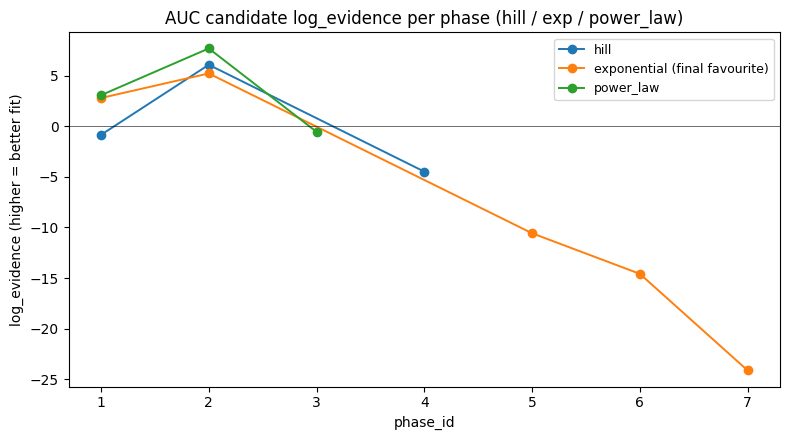

In [21]:
# v2 early-stopping diagnostic for the AUC task.
#
# Three convergence criteria across the three candidates (hill, exp, power_law):
#
#   1. Stability     -- same candidate picked in last 2 eps-greedy phases
#   2. Reward gap    -- top1 - top2 mean reward > 0.6 (above noise threshold)
#   3. Coverage      -- each candidate eps-greedy-picked at least once
#
# All three candidates (hill, exp, power_law) are genuinely competitive --
# no "guaranteed loser" here. The diagnostic reports the current leader and
# whether the gap is decisive. If all three
# criteria pass at some phase < 10, the v3 pitch becomes "phases needed for
# confident model selection".

TASK = "auc"

if TASK not in agent._task_state:
    print("AUC task state missing -- run hasn't reached BO phase.")
else:
    state = agent._task_state[TASK]
    hypo_log = state.get("hypothesis_log", [])
    candidates = list(agent.candidate_hypotheses_by_task[TASK])
    final = state.get("selected_hypothesis")
    record = state["record"]
    rewards = dict(zip(candidates, record[:, 1]))
    counts = dict(zip(candidates, record[:, 0].astype(int)))

    print(f"=== v2 EARLY-STOPPING REPORT (task = {TASK!r}) ===")
    print(f"Candidates: {candidates}")
    print(f"Final favourite: {final!r}")
    print()
    print("End-of-run record:")
    for c in candidates:
        tag = "  <-- selected" if c == final else ""
        print(f"  {c:>12s}: n={counts[c]:>2d}  reward={rewards[c]:+.3f}{tag}")

    # Reward gap (top1 - top2) -- now over all three candidates.
    sorted_rewards = sorted(rewards.values(), reverse=True)
    end_gap = (
        float(sorted_rewards[0] - sorted_rewards[1]) if len(sorted_rewards) > 1 else 0.0
    )
    decisive = end_gap > 0.6
    print()
    print(
        f"Top-1 - top-2 reward gap: {end_gap:.3f}  "
        f"({'DECISIVE (>0.6)' if decisive else 'NOISE-LEVEL (<0.6)'})"
    )

    if hypo_log:
        log_df = pd.DataFrame(hypo_log, columns=["phase_id", "name", "log_evidence"])
        log_df = log_df.sort_values(["phase_id", "name"]).reset_index(drop=True)
        counts_per_phase = log_df.groupby("phase_id")["name"].count()
        post_warmup_phase_ids = counts_per_phase[counts_per_phase == 1].index.tolist()
        post_warmup_picks = log_df[
            log_df["phase_id"].isin(post_warmup_phase_ids)
        ].sort_values("phase_id")[["phase_id", "name"]]
        print()
        print(f"Eps-greedy phases: {len(post_warmup_phase_ids)}")
        print("Eps-greedy picks (phase -> candidate):")
        for _, row in post_warmup_picks.iterrows():
            mark = "  (final favourite)" if row["name"] == final else ""
            print(f"  phase {int(row['phase_id']):>2d}: {row['name']}{mark}")

        # Stability: last 2 picks
        last_2 = post_warmup_picks["name"].tolist()[-2:]
        stable = len(last_2) == 2 and last_2[0] == last_2[1] == final
        print(f"\nLast 2 eps-greedy picks: {last_2}  -> stable on {final!r}? {stable}")

        # Coverage: each candidate eps-greedy-picked >= 1
        picked_set = set(post_warmup_picks["name"].tolist())
        coverage_ok = all(c in picked_set for c in candidates)
        missing = [c for c in candidates if c not in picked_set]
        print(
            f"Coverage: candidates picked = {sorted(picked_set)}  "
            f"({'ALL PICKED' if coverage_ok else f'MISSING: {missing}'})"
        )

        all_pass = stable and decisive and coverage_ok
        print()
        if all_pass:
            print(
                f"VERDICT: v2 converged on {final!r}. The slide claim 'lean BO + 3 distinct families"
            )
            print(
                f"         delivers confident model selection in {N_PHASES} phases (~{N_PHASES * N_FRAMES / 60:.1f} h)' is supported."
            )
        else:
            reasons = []
            if not stable:
                reasons.append("last 2 picks not stable")
            if not decisive:
                reasons.append(f"reward gap {end_gap:.2f} <= 0.6")
            if not coverage_ok:
                reasons.append(f"missing eps-greedy coverage: {missing}")
            print(f"VERDICT: NOT fully converged. Failed: {'; '.join(reasons)}")
            print(
                f"         If the gap is small AND the favourite is stable, the data may genuinely"
            )
            print(
                f"         not discriminate (hill/exp/power_law indistinguishable in this dose range) --"
            )
            print(f"         that is itself a scientific finding.")

    # Log-evidence trail: shows whether one candidate clearly dominates the
    # log-marginal-likelihood across phases. This is the figure for the slide.
    if hypo_log:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for c in candidates:
            sub = log_df[log_df["name"] == c].sort_values("phase_id")
            if sub.empty:
                continue
            label = c + (" (final favourite)" if c == final else "")
            ax.plot(
                sub["phase_id"], sub["log_evidence"], marker="o", lw=1.4, label=label
            )
        ax.set_xlabel("phase_id")
        ax.set_ylabel("log_evidence (higher = better fit)")
        ax.set_title("AUC candidate log_evidence per phase (hill / exp / power_law)")
        ax.legend(fontsize=9)
        ax.axhline(0, color="k", lw=0.4)
        plt.tight_layout()
        plt.show()

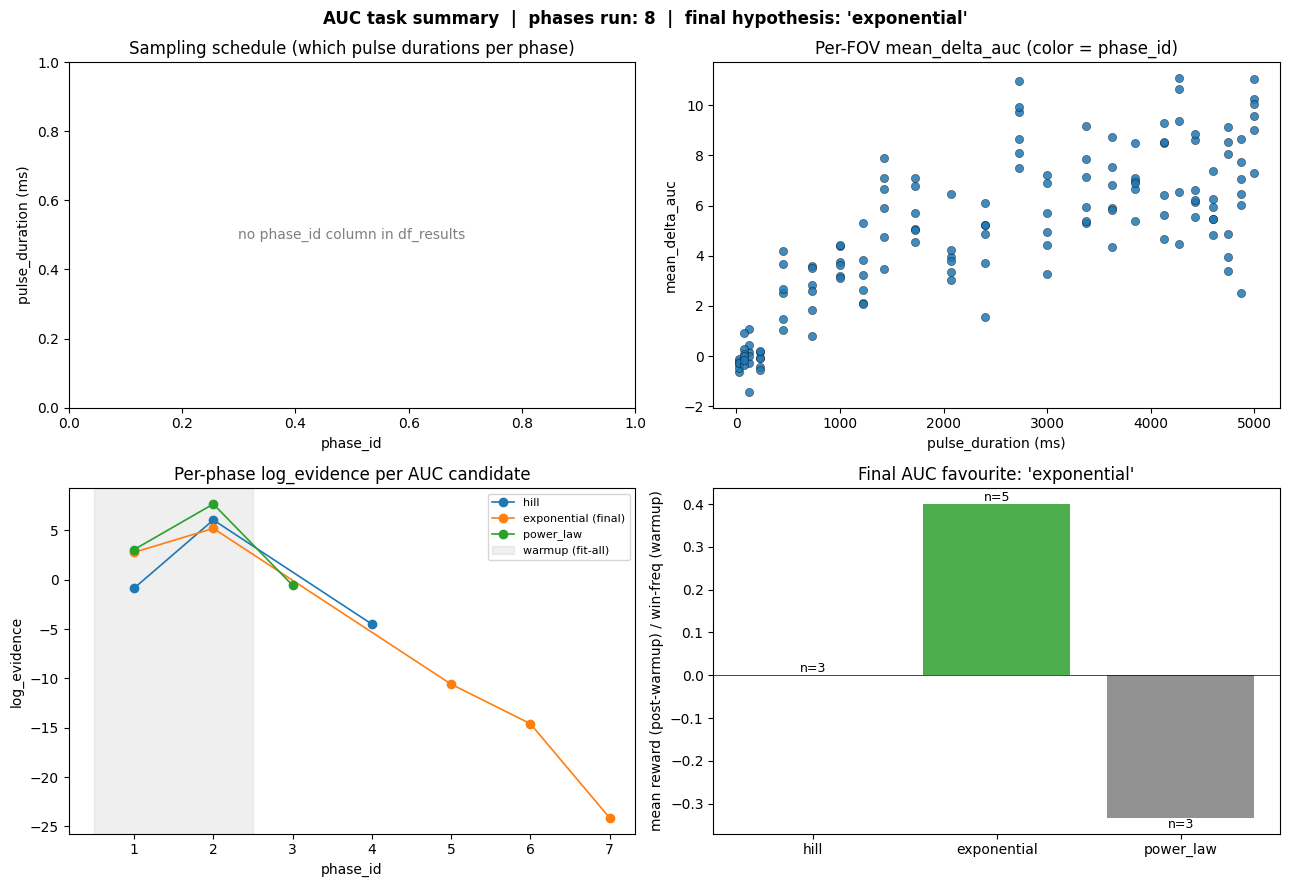


Final selected AUC hypothesis: 'exponential'
Mean reward per candidate (n = visit count):
          hill: reward=+0.000  n=3
   exponential: reward=+0.400  n=5  <-- selected
     power_law: reward=-0.333  n=3


In [22]:
# AUC-task summary: which pulse_duration was probed at which phase, and how the
# hypothesis log-evidence trajectory evolved per candidate (hill / linear / exponential).
#
# Panels:
#   (0,0) Sampling schedule    -- phase_id -> pulse_duration scatter (color = phase_id)
#   (0,1) Dose-response        -- pulse_duration -> mean_delta_auc (color = phase_id)
#   (1,0) Per-phase log_evidence for each AUC candidate (gaps = candidate not evaluated that phase)
#   (1,1) Current mean reward per candidate (final selected highlighted in green)
TASK = "auc"
task_col = agent.task_columns[TASK]

if agent.df_results is None or agent.df_results.empty:
    print("No data yet -- run the experiment first.")
else:
    df = agent.df_results.copy()
    state = agent._task_state[TASK]
    candidates = list(agent.candidate_hypotheses_by_task[TASK])
    hypo_log = state["hypothesis_log"]  # list of (phase_id, name, log_evidence)
    final = state["selected_hypothesis"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # --- (0,0) sampling schedule: phase_id vs pulse_duration ---
    ax = axes[0, 0]
    if "phase_id" in df.columns:
        sc = ax.scatter(
            df["phase_id"],
            df["pulse_duration"],
            c=df["phase_id"],
            cmap="viridis",
            s=35,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.85,
        )
        plt.colorbar(sc, ax=ax, label="phase_id")
    else:
        ax.text(
            0.5,
            0.5,
            "no phase_id column in df_results",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    ax.set_xlabel("phase_id")
    ax.set_ylabel("pulse_duration (ms)")
    ax.set_title("Sampling schedule (which pulse durations per phase)")

    # --- (0,1) dose-response, phase-colored ---
    ax = axes[0, 1]
    if "phase_id" in df.columns:
        sc = ax.scatter(
            df["pulse_duration"],
            df[task_col],
            c=df["phase_id"],
            cmap="viridis",
            s=35,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.85,
        )
        plt.colorbar(sc, ax=ax, label="phase_id")
    else:
        ax.scatter(
            df["pulse_duration"],
            df[task_col],
            s=35,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.85,
        )
    ax.set_xlabel("pulse_duration (ms)")
    ax.set_ylabel(task_col)
    ax.set_title(f"Per-FOV {task_col} (color = phase_id)")

    # --- (1,0) per-phase log_evidence for each candidate ---
    ax = axes[1, 0]
    if not hypo_log:
        ax.text(
            0.5,
            0.5,
            "hypothesis_log is empty\n(run did not reach BO phase)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        log_df = pd.DataFrame(hypo_log, columns=["phase_id", "name", "log_evidence"])
        cmap = plt.get_cmap("tab10")
        for i, name in enumerate(candidates):
            sub = log_df[log_df["name"] == name].sort_values("phase_id")
            if sub.empty:
                continue
            ax.plot(
                sub["phase_id"],
                sub["log_evidence"],
                marker="o",
                lw=1.2,
                color=cmap(i),
                label=f"{name}" + (" (final)" if name == final else ""),
            )
        # Shade warmup region.
        n_warm = agent.n_warmup_phases
        if log_df["phase_id"].min() is not np.nan and n_warm > 0:
            warm_start = int(log_df["phase_id"].min())
            ax.axvspan(
                warm_start - 0.5,
                warm_start + n_warm - 0.5,
                color="gray",
                alpha=0.12,
                label="warmup (fit-all)",
            )
        ax.set_xlabel("phase_id")
        ax.set_ylabel("log_evidence")
        ax.set_title(f"Per-phase log_evidence per AUC candidate")
        ax.legend(fontsize=8, loc="best")

    # --- (1,1) final mean reward per candidate ---
    ax = axes[1, 1]
    rewards = state["record"][:, 1]
    counts = state["record"][:, 0]
    colors = ["tab:green" if name == final else "tab:gray" for name in candidates]
    bars = ax.bar(candidates, rewards, color=colors, alpha=0.85)
    for bar, n in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"n={int(n)}",
            ha="center",
            va="bottom" if bar.get_height() >= 0 else "top",
            fontsize=9,
        )
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("mean reward (post-warmup) / win-freq (warmup)")
    ax.set_title(f"Final AUC favourite: {final!r}")

    fig.suptitle(
        f"AUC task summary  |  phases run: {len(agent._iteration_means)}  |  "
        f"final hypothesis: {final!r}",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Compact text summary
    print(f"\nFinal selected AUC hypothesis: {final!r}")
    print("Mean reward per candidate (n = visit count):")
    for name, r, n in zip(candidates, rewards, counts):
        flag = "  <-- selected" if name == final else ""
        print(f"  {name:>12s}: reward={r:+.3f}  n={int(n)}{flag}")

UnboundLocalError: cannot access local variable 'i' where it is not associated with a value

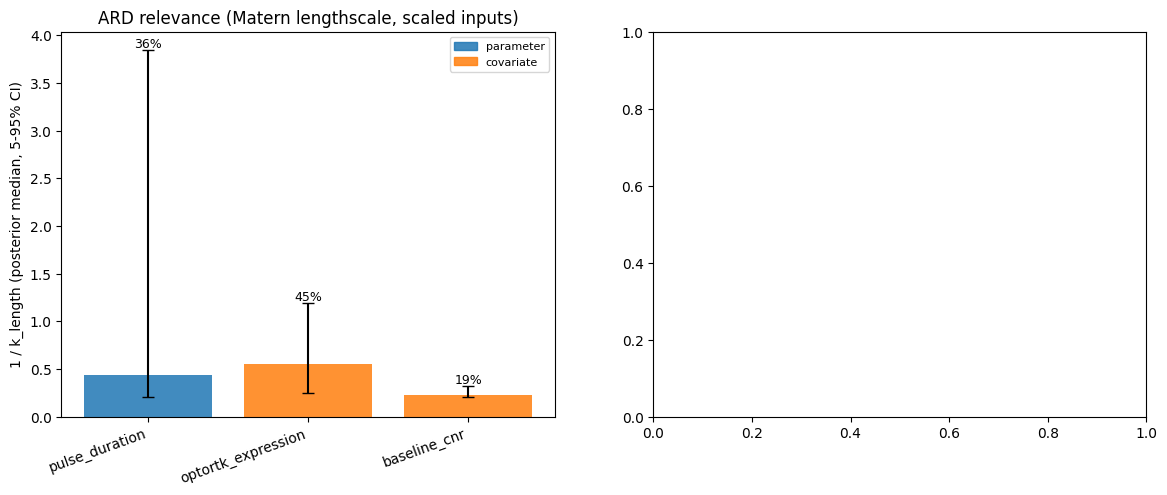

In [23]:
# Covariate-contribution diagnostics for the AUC task.
#
# Two complementary views:
#
#   LEFT  -- ARD relevance: posterior of 1 / k_length per input dim.
#            Matern + ARD learns a separate lengthscale for each input;
#            short lengthscale = GP varies quickly along that dim to explain
#            the data = informative. Bars are posterior median, error bars
#            are the 5-95% credible interval (over MCMC samples).
#            *Caveat*: lengthscale_prior_dist = Uniform(0.1, 1.0) so 1/k_length
#            is bounded in [1, 10] -- ratios across dims, not absolute values,
#            are the meaningful quantity.
#
#   RIGHT -- Decision sensitivity: hold pulse_duration at a low / mid / high
#            representative value and the other covariates at their median;
#            sweep one covariate across its 5-95% observed range; record
#            the predicted mean_delta_auc swing (max - min). Bigger swing
#            = ignoring that covariate would distort predictions more.
#            *Caveat*: one-at-a-time, ignores interactions.

import gpax
import gpax.utils

TASK = "auc"

if (
    TASK not in agent._gp_models_by_task
    or agent.df_results is None
    or agent.df_results.empty
):
    print("AUC GP not fit yet -- run the experiment first.")
else:
    gp = agent._gp_models_by_task[TASK]
    y_scaler = agent._y_scalers_by_task[TASK]
    x_scaler = agent._x_scaler

    param_names = [p.name for p in agent.parameters_to_optimize]
    cov_names = [c.name for c in agent.bo_covariates]
    dim_names = param_names + cov_names  # GP input order: params first, then covariates
    n_params = len(param_names)

    samples = gp.get_samples(chain_dim=False)
    if "k_length" not in samples:
        print("k_length not in MCMC samples -- non-ARD kernel? skipping ARD panel.")
        k_length = None
    else:
        k_length = np.asarray(samples["k_length"])  # (S, D) in scaled-input space

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------- LEFT: ARD relevance per input dim ----------
    ax = axes[0]
    if k_length is None or k_length.ndim != 2 or k_length.shape[1] != len(dim_names):
        ax.text(
            0.5,
            0.5,
            "k_length not available or shape mismatch",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        relevance = 1.0 / k_length
        rel_med = np.median(relevance, axis=0)
        rel_lo = np.quantile(relevance, 0.05, axis=0)
        rel_hi = np.quantile(relevance, 0.95, axis=0)
        rel_pct = 100.0 * rel_med / rel_med.sum()
        colors = [
            "tab:blue" if i < n_params else "tab:orange" for i in range(len(dim_names))
        ]
        ax.bar(
            dim_names,
            rel_med,
            yerr=[rel_med - rel_lo, rel_hi - rel_med],
            color=colors,
            alpha=0.85,
            capsize=4,
        )
        for i, pct in enumerate(rel_pct):
            ax.text(i, rel_hi[i], f"{pct:.0f}%", ha="center", va="bottom", fontsize=9)
        ax.set_ylabel("1 / k_length (posterior median, 5-95% CI)")
        ax.set_title("ARD relevance (Matern lengthscale, scaled inputs)")
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
        legend_handles = [
            plt.Rectangle(
                (0, 0), 1, 1, color="tab:blue", alpha=0.85, label="parameter"
            ),
            plt.Rectangle(
                (0, 0), 1, 1, color="tab:orange", alpha=0.85, label="covariate"
            ),
        ]
        ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

    # ---------- RIGHT: predictive sensitivity sweep ----------
    ax = axes[1]
    df = agent.df_results
    cov_vals = df[cov_names].to_numpy(dtype=float)
    cov_med = np.median(cov_vals, axis=0)
    pulse_obs = df[param_names[0]].to_numpy()
    pulse_repr = np.quantile(pulse_obs, [0.1, 0.5, 0.9])
    n_sweep = 25

    rng_key, rng_key_pred = gpax.utils.get_keys()
    sensitivities = np.zeros((len(pulse_repr), len(cov_names)))

    for j, pulse_fixed in enumerate(pulse_repr):
        for i, _cov_name in enumerate(cov_names):
            cov_range = np.linspace(
                np.quantile(cov_vals[:, i], 0.05),
                np.quantile(cov_vals[:, i], 0.95),
                n_sweep,
            )
            cov_sweep = np.tile(cov_med, (n_sweep, 1))
            cov_sweep[:, i] = cov_range
            x_full = np.column_stack([np.full(n_sweep, pulse_fixed), cov_sweep])
            x_scaled = x_scaler.transform(x_full)
            y_pred_scaled, _ = gp.predict_in_batches(
                rng_key_pred,
                x_scaled,
                batch_size=1000,
                n=4,
                noiseless=True,
            )
            y_pred = y_scaler.inverse_transform(
                np.asarray(y_pred_scaled).reshape(-1, 1)
            ).flatten()
            sensitivities[j, i] = y_pred.max() - y_pred.min()

    bar_width = 0.25
    x = np.arange(len(cov_names))
    for j, pulse_fixed in enumerate(pulse_repr):
        ax.bar(
            x + (j - 1) * bar_width,
            sensitivities[j],
            width=bar_width,
            label=f"pulse={pulse_fixed:.0f} ms",
            alpha=0.85,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(cov_names, rotation=20, ha="right")
    ax.set_ylabel(
        "predicted mean_delta_auc swing\n(max - min over 5-95% covariate range)"
    )
    ax.set_title("Decision sensitivity (one-at-a-time, others fixed at median)")
    ax.legend(fontsize=8)

    fig.suptitle(
        "AUC task -- how much do covariates contribute?", fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # ----- Text summary -----
    if k_length is not None and k_length.shape[1] == len(dim_names):
        print("ARD relevance ranking (higher = more informative input):")
        order = np.argsort(rel_med)[::-1]
        for idx in order:
            kind = "param" if idx < n_params else "covariate"
            print(
                f"  {dim_names[idx]:>22s} ({kind:>9s}): "
                f"1/l = {rel_med[idx]:.3f}  ({rel_pct[idx]:.1f}% of total)"
            )

    print(
        "\nDecision sensitivity (predicted AUC swing per covariate, averaged over pulse levels):"
    )
    sens_mean = sensitivities.mean(axis=0)
    for i, name in enumerate(cov_names):
        print(
            f"  {name:>22s}: avg swing = {sens_mean[i]:.4f}  "
            f"(low={sensitivities[0, i]:.4f}, mid={sensitivities[1, i]:.4f}, "
            f"high={sensitivities[2, i]:.4f})"
        )

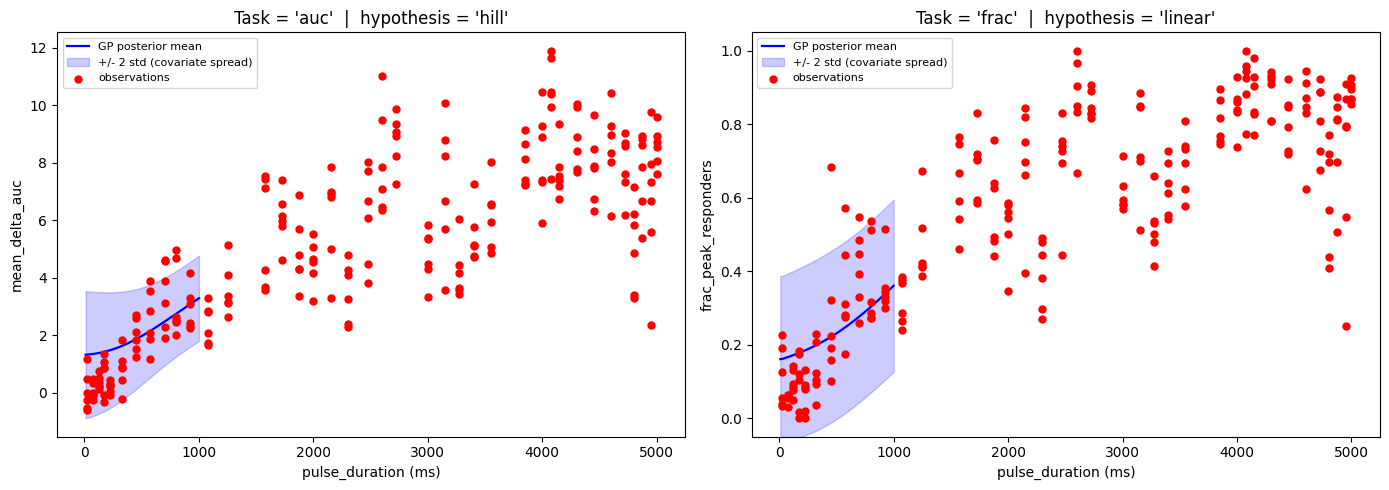

In [ ]:
# GP-predicted dose-response curves per task (marginalised over covariates).
import gpax
import gpax.utils

if (
    agent._gp_models_by_task
    and agent.df_results is not None
    and not agent.df_results.empty
):
    df = agent.df_results

    rng_key, rng_key_pred = gpax.utils.get_keys()
    pulse_grid = np.arange(10.0, 1000.0 + 10.0, 10.0)

    n_cov_samples = 50
    cov_vals = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
    rng = np.random.default_rng(0)
    cov_idx = rng.integers(0, cov_vals.shape[0], size=n_cov_samples)
    cov_samples = cov_vals[cov_idx]

    x_full = np.hstack(
        [
            np.repeat(pulse_grid[:, None], n_cov_samples, axis=0),
            np.tile(cov_samples, (len(pulse_grid), 1)),
        ]
    )
    x_full_scaled = agent._x_scaler.transform(x_full)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax_idx, task in enumerate(agent.TASKS):
        ax = axes[ax_idx]
        gp_model = agent._gp_models_by_task[task]
        y_scaler = agent._y_scalers_by_task[task]
        col = agent.task_columns[task]

        y_pred_scaled, _ = gp_model.predict_in_batches(
            rng_key_pred,
            x_full_scaled,
            batch_size=1000,
            n=8,
            noiseless=True,
        )
        y_pred_logit_or_lin = y_scaler.inverse_transform(
            np.asarray(y_pred_scaled).reshape(-1, 1)
        ).flatten()
        # If task is logit-scaled, invert back to probability space.
        if agent.task_logit[task]:
            y_pred = _inv_logit(y_pred_logit_or_lin)
        else:
            y_pred = y_pred_logit_or_lin

        y_pred_2d = y_pred.reshape(len(pulse_grid), n_cov_samples)
        y_pred_mean = y_pred_2d.mean(axis=1)
        y_pred_std = y_pred_2d.std(axis=1)

        ax.plot(pulse_grid, y_pred_mean, "b-", lw=1.6, label="GP posterior mean")
        ax.fill_between(
            pulse_grid,
            y_pred_mean - 2 * y_pred_std,
            y_pred_mean + 2 * y_pred_std,
            alpha=0.2,
            color="blue",
            label="+/- 2 std (covariate spread)",
        )
        ax.scatter(
            df["pulse_duration"],
            df[col],
            c="red",
            s=25,
            zorder=5,
            label="observations",
        )
        ax.set_xlabel("pulse_duration (ms)")
        ax.set_ylabel(col)
        locked = agent._task_state[task]["selected_hypothesis"]
        ax.set_title(
            f"Task = {task!r}  |  hypothesis = {locked!r}"
            if locked
            else f"Task = {task!r}  (current best, not yet locked)"
        )
        ax.legend(fontsize=8)
        if agent.task_logit[task]:
            ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()
else:
    print("GPs not fit yet (run hasn't reached BO phase).")

=== Winning model: 'exponential'  (task = 'auc') ===
Parameter posteriors (median, 95% CI):

               A (asymptote) (     exp_amp): median =     9.31      AUC   std =    2.19   95% CI: [5.45, 13.3]
         tau (time constant) (     exp_tau): median = 1.74e+03       ms   std = 2.07e+03   95% CI: [644, 7.07e+03]


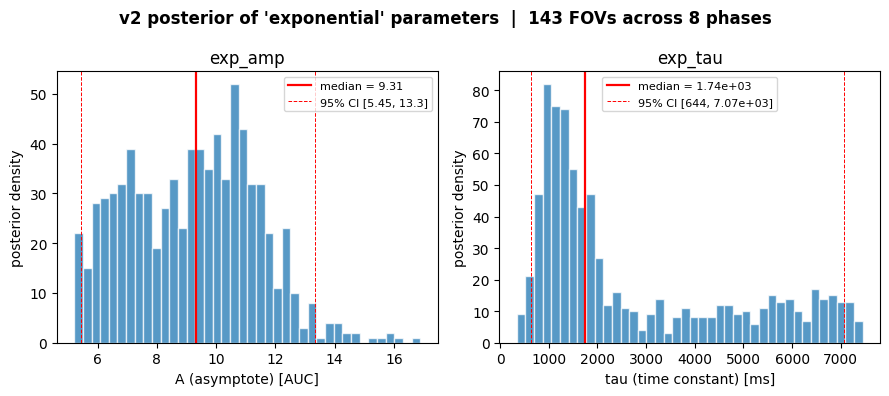

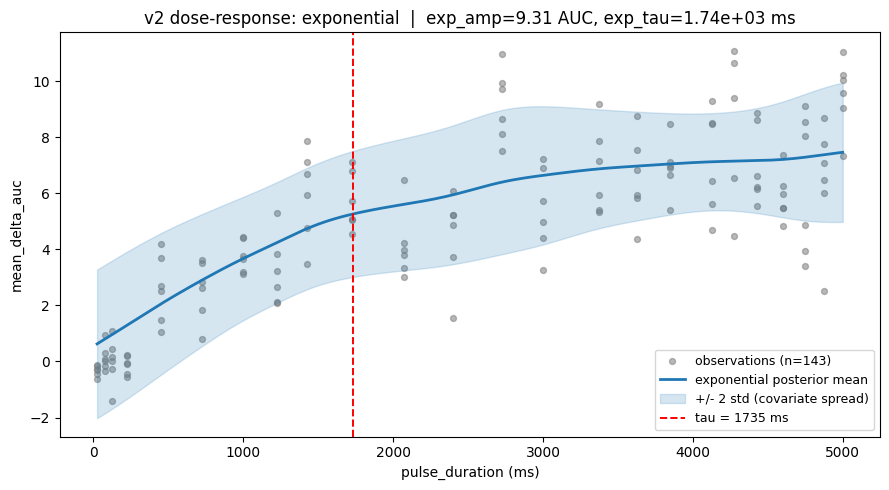


Slide-ready summary:
  "v2 fit: exponential-saturation dose-response with tau = 1735 +/- 2066 ms, asymptote A = 9.31 +/- 2.19 AUC, at 8 phases (~4.1 h microscope time)."


In [24]:
# Winning-model parameter posteriors (the actual scientific output of v2).
#
# Hypothesis-learning picks the *family* (hill / exp / power_law); the
# parameter posteriors below pin down WHERE on that family the data lies.
# Together they are the dose-response result. For Hill these are:
#   - V_max: response asymptote (AUC units)
#   - K     : EC50 dose (ms)  <-- the headline biological number
#   - n     : Hill coefficient (unitless; n > 1 = cooperative / sigmoidal)
# For exp:    A (asymptote), tau (time constant, ms)
# For power_law: a (prefactor at midpoint dose), b (exponent, unitless)
#
# Dose-space parameters are converted from the GP's standardised input space
# back to milliseconds; y-space parameters (asymptotes, prefactors) are
# converted from standardised AUC back to raw AUC via the y_scaler.

import numpy as np

TASK = "auc"

if (
    TASK not in agent._gp_models_by_task
    or agent.df_results is None
    or agent.df_results.empty
):
    print("Run hasn't reached BO phase yet -- no winning model.")
else:
    state = agent._task_state[TASK]
    final = state.get("selected_hypothesis")
    gp = agent._gp_models_by_task[TASK]
    y_scaler = agent._y_scalers_by_task[TASK]
    samples = gp.get_samples(chain_dim=False)

    # --- Dose-space <-> ms conversion (matches StandardScalerBounds + _shifted_dose) ---
    pulse_min_ms = bo_params[0].bounds[0]
    pulse_max_ms = bo_params[0].bounds[1]

    def shifted_to_ms(d_shifted_arr):
        # _shifted_dose maps scaled_dose [-1, 1] -> shifted [0, 2]
        # StandardScalerBounds maps original [min, max] -> scaled [-1, 1]
        # So: ms = shifted/2 * (max - min) + min
        d_shifted_arr = np.asarray(d_shifted_arr, dtype=float)
        return d_shifted_arr / 2.0 * (pulse_max_ms - pulse_min_ms) + pulse_min_ms

    def yscaled_to_raw(arr):
        arr = np.asarray(arr, dtype=float).reshape(-1, 1)
        return y_scaler.inverse_transform(arr).flatten()

    # --- Parameter specs per candidate ---
    # Each tuple: (sample_key, display_label, conversion, unit)
    # conversions: "dose_to_ms" | "yscaled_to_raw" | "raw"
    PARAM_SPECS = {
        "hill": [
            ("hill_vmax", "V_max (asymptote)", "yscaled_to_raw", "AUC"),
            ("hill_k", "K (EC50)", "dose_to_ms", "ms"),
            ("hill_n", "n (Hill coefficient)", "raw", "unitless"),
        ],
        "exponential": [
            ("exp_amp", "A (asymptote)", "yscaled_to_raw", "AUC"),
            ("exp_tau", "tau (time constant)", "dose_to_ms", "ms"),
        ],
        "power_law": [
            ("pow_a", "a (AUC at midpoint dose)", "yscaled_to_raw", "AUC"),
            ("pow_b", "b (exponent)", "raw", "unitless"),
        ],
    }

    if final not in PARAM_SPECS:
        print(f"No parameter spec defined for {final!r}.")
    else:
        specs = PARAM_SPECS[final]
        present = [(k, lbl, conv, unit) for k, lbl, conv, unit in specs if k in samples]
        missing = [k for k, *_ in specs if k not in samples]
        if missing:
            print(f"WARN: missing sample keys: {missing}")

        # --- Parameter posterior histograms ---
        fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present), 4))
        if len(present) == 1:
            axes = [axes]

        print(f"=== Winning model: {final!r}  (task = {TASK!r}) ===")
        print(f"Parameter posteriors (median, 95% CI):\n")
        param_rows = []  # for the summary table
        for ax, (key, label, conv, unit) in zip(axes, present):
            s_scaled = np.asarray(samples[key])
            if conv == "dose_to_ms":
                s = shifted_to_ms(s_scaled)
            elif conv == "yscaled_to_raw":
                s = yscaled_to_raw(s_scaled)
            else:
                s = s_scaled
            med = float(np.median(s))
            lo = float(np.quantile(s, 0.025))
            hi = float(np.quantile(s, 0.975))
            std = float(np.std(s))
            param_rows.append((label, key, med, std, lo, hi, unit))

            ax.hist(s, bins=40, color="tab:blue", alpha=0.75, edgecolor="white")
            ax.axvline(med, color="red", lw=1.6, label=f"median = {med:.3g}")
            ax.axvline(lo, color="red", lw=0.7, ls="--")
            ax.axvline(
                hi, color="red", lw=0.7, ls="--", label=f"95% CI [{lo:.3g}, {hi:.3g}]"
            )
            ax.set_xlabel(f"{label} [{unit}]")
            ax.set_ylabel("posterior density")
            ax.set_title(f"{key}")
            ax.legend(fontsize=8, loc="best")

            print(
                f"  {label:>26s} ({key:>12s}): "
                f"median = {med:>8.3g} {unit:>8s}   "
                f"std = {std:>7.3g}   "
                f"95% CI: [{lo:.3g}, {hi:.3g}]"
            )

        fig.suptitle(
            f"v2 posterior of {final!r} parameters  |  "
            f"{len(agent.df_results)} FOVs across {agent.iteration} phases",
            fontsize=12,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

        # --- Bonus: overlay the fitted curve on data with parameter labels ---
        import gpax.utils

        rng_key, rng_key_pred = gpax.utils.get_keys()
        pulse_grid = np.linspace(pulse_min_ms, pulse_max_ms, 200)

        df_res = agent.df_results
        cov_vals = df_res[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
        n_cov_samples = 50
        rng = np.random.default_rng(0)
        cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_cov_samples)]

        x_full = np.hstack(
            [
                np.repeat(pulse_grid[:, None], n_cov_samples, axis=0),
                np.tile(cov_samples, (len(pulse_grid), 1)),
            ]
        )
        x_full_scaled = agent._x_scaler.transform(x_full)

        y_pred_scaled, _ = gp.predict_in_batches(
            rng_key_pred,
            x_full_scaled,
            batch_size=1000,
            n=8,
            noiseless=True,
        )
        y_pred = yscaled_to_raw(np.asarray(y_pred_scaled))
        y_pred_2d = y_pred.reshape(len(pulse_grid), n_cov_samples)
        y_mean = y_pred_2d.mean(axis=1)
        y_std = y_pred_2d.std(axis=1)

        fig2, ax2 = plt.subplots(figsize=(9, 5))
        ax2.scatter(
            df_res["pulse_duration"],
            df_res["mean_delta_auc"],
            c="tab:gray",
            s=18,
            alpha=0.55,
            label=f"observations (n={len(df_res)})",
        )
        ax2.plot(
            pulse_grid, y_mean, color="tab:blue", lw=2, label=f"{final} posterior mean"
        )
        ax2.fill_between(
            pulse_grid,
            y_mean - 2 * y_std,
            y_mean + 2 * y_std,
            alpha=0.18,
            color="tab:blue",
            label="+/- 2 std (covariate spread)",
        )

        # Annotate EC50 / tau on the plot if applicable
        if final == "hill":
            K_med = next((r[2] for r in param_rows if r[1] == "hill_k"), None)
            if K_med is not None:
                ax2.axvline(
                    K_med, color="red", ls="--", lw=1.4, label=f"K = {K_med:.0f} ms"
                )
        elif final == "exponential":
            tau_med = next((r[2] for r in param_rows if r[1] == "exp_tau"), None)
            if tau_med is not None:
                ax2.axvline(
                    tau_med,
                    color="red",
                    ls="--",
                    lw=1.4,
                    label=f"tau = {tau_med:.0f} ms",
                )

        ax2.set_xlabel("pulse_duration (ms)")
        ax2.set_ylabel("mean_delta_auc")
        param_pretty = ", ".join(f"{r[1]}={r[2]:.3g} {r[6]}" for r in param_rows)
        ax2.set_title(f"v2 dose-response: {final}  |  {param_pretty}")
        ax2.legend(fontsize=9, loc="lower right")
        plt.tight_layout()
        plt.show()

        # --- Slide-ready summary line ---
        print()
        print("Slide-ready summary:")
        if final == "hill":
            K = next(r[2] for r in param_rows if r[1] == "hill_k")
            K_std = next(r[3] for r in param_rows if r[1] == "hill_k")
            n_med = next(r[2] for r in param_rows if r[1] == "hill_n")
            n_std = next(r[3] for r in param_rows if r[1] == "hill_n")
            V = next(r[2] for r in param_rows if r[1] == "hill_vmax")
            V_std = next(r[3] for r in param_rows if r[1] == "hill_vmax")
            print(
                f'  "v2 fit: Hill dose-response with EC50 K = {K:.0f} +/- {K_std:.0f} ms, '
                f"Hill coefficient n = {n_med:.2f} +/- {n_std:.2f}, asymptote V_max = {V:.2f} +/- {V_std:.2f} AUC, "
                f'at {agent.iteration} phases (~{agent.iteration * N_FRAMES / 60:.1f} h microscope time)."'
            )
        elif final == "exponential":
            tau = next(r[2] for r in param_rows if r[1] == "exp_tau")
            tau_std = next(r[3] for r in param_rows if r[1] == "exp_tau")
            A = next(r[2] for r in param_rows if r[1] == "exp_amp")
            A_std = next(r[3] for r in param_rows if r[1] == "exp_amp")
            print(
                f'  "v2 fit: exponential-saturation dose-response with tau = {tau:.0f} +/- {tau_std:.0f} ms, '
                f"asymptote A = {A:.2f} +/- {A_std:.2f} AUC, "
                f'at {agent.iteration} phases (~{agent.iteration * N_FRAMES / 60:.1f} h microscope time)."'
            )
        elif final == "power_law":
            b = next(r[2] for r in param_rows if r[1] == "pow_b")
            b_std = next(r[3] for r in param_rows if r[1] == "pow_b")
            print(
                f'  "v2 fit: power-law dose-response with exponent b = {b:.2f} +/- {b_std:.2f}, '
                f"no saturation within 25-5000 ms, "
                f'at {agent.iteration} phases (~{agent.iteration * N_FRAMES / 60:.1f} h microscope time)."'
            )